# Liquidation-signal EDA

Maker-trade filtering on Exchange 1 `perp:btcusdt` / `perp:ethusdt` using liquidation flow. Data is
three months (Dec 2025 – Feb 2026) of Exchange 1 trades, BBO, and liquidations plus Exchange 2
liquidations; train is Dec–Jan, validation is Feb.

**Directional liquidation signal.** Once you account for short-horizon queue-imbalance adverse
selection, liquidations still carry a separate, longer-horizon, *directional* signal in maker
markout: a maker filled **against** a cascade (selling into a buy-cascade) sees the reversion
(markout ~+1.7 bps BTC / +2.3 bps ETH at τ=300 s), filled *with* it loses about the same. A single
liquidation print **lags** the move, so it's a poor trigger; the signal is the windowed cascade
*direction* relative to the fill side, not the raw liquidation size.

The heavy compute (full 400M/700M-row trades and BBO) runs offline in `eda_compute.py` and is
cached to `eda_results/`; this notebook only loads those artifacts, so it opens fast and uses
little memory. Regenerate with `python eda_compute.py {quirks|fast|micro|leadlag|conditional|markout|all}`.

**Sections:** 1 · data inventory & quirks · 2 · liquidation structure · 3 · microstructure
(imbalance, order-flow memory, lead-lag, liq-price offset) · 4 · markout, event study, adverse
selection, and features. A companion `../task_2_features_shaw/feature_infra_demo.ipynb`
demonstrates the leak-safe feature package.

## 1 · Data inventory and quirks

A careful catalogue of the dataset's gotchas: the things that are easy to miss and that
change how the signal must be built. Evidence is precomputed once (`python eda_compute.py
quirks`, memory-safe, ~2 min) into `eda_results/quirks_*`.

| # | Quirk | Evidence | Why it matters |
|---|---|---|---|
| 1 | **Microseconds are a lie**, every feed is millisecond-resolution | 100% of timestamps in all 6 files are multiples of 1000 µs | "µs since epoch" is really ms; "455 trades per µs" was per **ms**; co-timestamping is at ms |
| 2 | **Exchange 1 liquidations are rate-limited to ≈1/s**; Exchange 2 fires every event | Exchange 1 min inter-arrival ~0.83–0.95 s (effectively no sub-second bursts); Exchange 2 0.0 s, 83% of gaps < 0.9 s | Exchange 1 **under-counts cascades** (≈1 print/s). Use Exchange 2 for intensity, Exchange 1 as confirmation |
| 3 | **Trades come in same-millisecond sweeps** | distinct timestamps only 21% (BTC) / 15% (ETH); up to **588 / 726 fills in one ms** | one aggressive order = many sub-fills sharing a ms; aggregate per-ms, don't treat fills as independent |
| 4 | **The book ticker goes silent for minutes** | BBO max gap **199 s (BTC) / 354 s (ETH)**; only 7–8 gaps ≥ 10 s | forward-filled mid can be minutes stale → markout at t+τ unreliable inside a gap (rare but extreme) |
| 5 | **Trade feed has ~46 s outages, on both symbols at once** | 13 (BTC) / 4 (ETH) gaps > 10 s; max **46.4 / 46.3 s**, near-identical | a liquid perp doesn't go 46 s without a trade → **collection outage**, treat as missing |
| 6 | **Exchange 2 needs sorting (+ drop exact-dup rows)** | non-monotonic; **3–4% duplicate** timestamps; only a few **exact**-duplicate rows | sort before merge; drop **only exact duplicates** (same-ms events are distinct, keep them); apply the **+200 ms** shift |
| 7 | **Clean books, fixed grids** | 0 crossed / 0 locked / 0 zero-size; tick **\$0.1 (BTC) / \$0.01 (ETH)**, lot 0.001 | no book repair needed; tick/lot for normalisation |
| 8 | **Sell-side skew in a crash** | sell-liq 56% (Exchange 1) / 67% (Exchange 2); BTC traded **\$97.9k → \$59.8k** | the sample is a downtrend; long liquidations dominate; Feb (val) is the stressed leg |
| 9 | **No funding-time clustering** (corrected) | within ±60 s of 00/08/16 UTC = 0.21–0.32% vs **0.42% uniform** → at/below chance | earlier "2.3×" used a wrong baseline (missing ×3 windows), no funding effect |
| 10 | **Regime shift + opposite BTC/ETH** | events/day ×1.4–1.85 train→val; **BTC val markout negative, ETH positive** | the #1 out-of-sample risk; BTC and ETH likely need separate treatment |

In [1]:
import json
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
OUT = "eda_results"
Q = json.load(open(f"{OUT}/quirks_summary.json"))
from pathlib import Path as _P
DATA = next((str(d / "liquidation_task" / "data") for d in (_P.cwd(), *_P.cwd().parents)
             if (d / "liquidation_task" / "data").is_dir()), "liquidation_task/data")
def liq(ex, sym):
    p = f"{DATA}/{'exchange_1_liquidations/perp_' if ex=='exchange_1' else 'exchange_2_liquidations/'}{sym}usdt.parquet"
    return pl.read_parquet(p)

### 1 · Microseconds are a lie: the data is millisecond-resolution

Timestamps are stored as µs since epoch, but in every file **100% are multiples of 1000**,
the true clock is 1 ms. So sub-millisecond ordering is meaningless, and earlier talk of
"hundreds of trades per microsecond" is really *per millisecond*.

In [2]:
rows = []
for grp, d in Q.items():
    for name, v in d.items():
        if "pct_ms_granular" in v:
            rows.append({"feed": f"{grp}:{name}", "pct_ms_granular": round(v["pct_ms_granular"], 1)})
pl.DataFrame(rows)

feed,pct_ms_granular
str,f64
"""liquidations:exchange_1_btc""",100.0
"""liquidations:exchange_1_eth""",100.0
"""liquidations:exchange_2_btc""",100.0
"""liquidations:exchange_2_eth""",100.0
"""bbo:btc""",100.0
"""bbo:eth""",100.0


### 2 · Exchange 1 liquidations are throttled to ~1 s; Exchange 2 reports every event

The most important quirk for the signal. Exchange 1's force-order feed emits **at most ~1
print per second** (min inter-arrival ~0.9 s, no sub-second bursts), so it collapses a violent
cascade into one row per second. Exchange 2 is true per-event (ms precision, 83% of gaps < 0.9 s).
**Liquidation intensity must come from Exchange 2; Exchange 1 is only confirmation.**

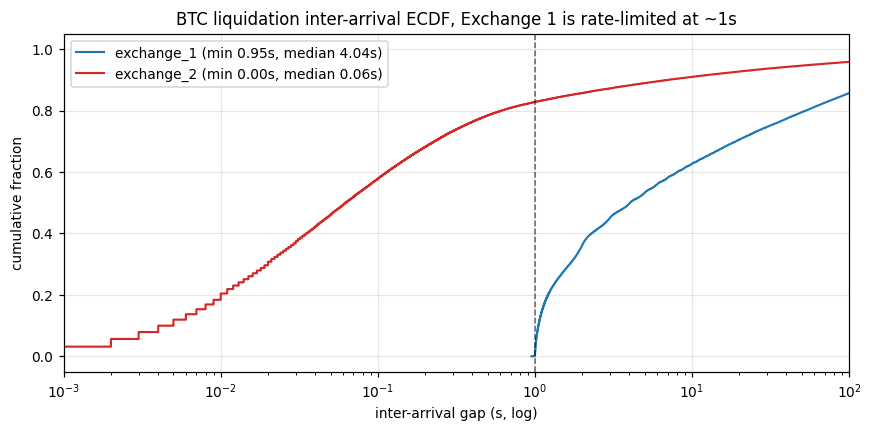

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for ex, c in [("exchange_1", "#1f77b4"), ("exchange_2", "#d62728")]:
    g = np.diff(liq(ex, "btc")["timestamp"].sort().to_numpy()) / 1e6
    g = np.sort(g[g > 0])
    ax.step(g, np.arange(len(g)) / len(g), color=c, lw=1.4,
            label=f"{ex} (min {Q['liquidations'][ex+'_btc']['min_gap_s']:.2f}s, "
                  f"median {Q['liquidations'][ex+'_btc']['median_gap_s']:.2f}s)")
ax.axvline(1.0, color="k", ls="--", lw=1, alpha=0.6)
ax.set_xscale("log"); ax.set_xlim(1e-3, 1e2)
ax.set(title="BTC liquidation inter-arrival ECDF, Exchange 1 is rate-limited at ~1s",
       xlabel="inter-arrival gap (s, log)", ylabel="cumulative fraction")
ax.legend(); plt.tight_layout(); plt.show()

### 3 · Trades arrive in same-millisecond sweeps

A single aggressive market order is reported as many sub-fills that share one ms timestamp.
Distinct timestamps are only ~15–21% of rows, and a single ms can hold **hundreds** of fills.
Treat the per-ms group as one event (aggregate notional / VWAP), not independent trades.

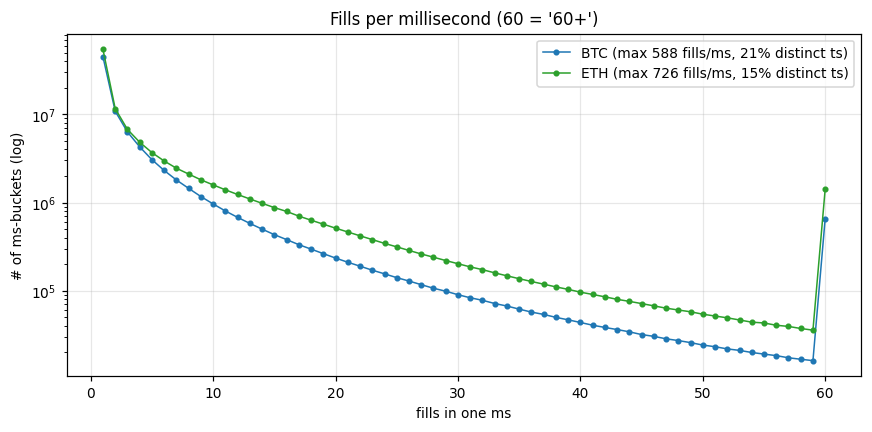

In [4]:
bh = pl.read_parquet(f"{OUT}/quirks_burst_hist.parquet")
fig, ax = plt.subplots(figsize=(8, 4))
for sym, c in [("btc", "#1f77b4"), ("eth", "#2ca02c")]:
    s = bh.filter(pl.col("symbol") == sym).sort("fills")
    ax.plot(s["fills"], s["n"], marker=".", lw=1, color=c,
            label=f"{sym.upper()} (max {Q['trades'][sym]['max_fills_per_ms']} fills/ms, "
                  f"{Q['trades'][sym]['distinct_ts_pct']:.0f}% distinct ts)")
ax.set_yscale("log")
ax.set(title="Fills per millisecond (60 = '60+')", xlabel="fills in one ms", ylabel="# of ms-buckets (log)")
ax.legend(); plt.tight_layout(); plt.show()

### 4 · The book ticker goes silent for minutes · 5 · Trade feed has synchronized ~46 s outages

BBO updates are usually sub-second, but there are a handful of **multi-minute** silences
(max 199 s BTC / 354 s ETH), during them a forward-filled mid is badly stale, which corrupts
markout at `t+τ`. The trade feed has its own gaps up to **~46 s on both symbols at nearly the
same length** (46.4 vs 46.3 s), too long for a liquid perp and synchronized across symbols,
so it is a **collection outage**, not a quiet market.

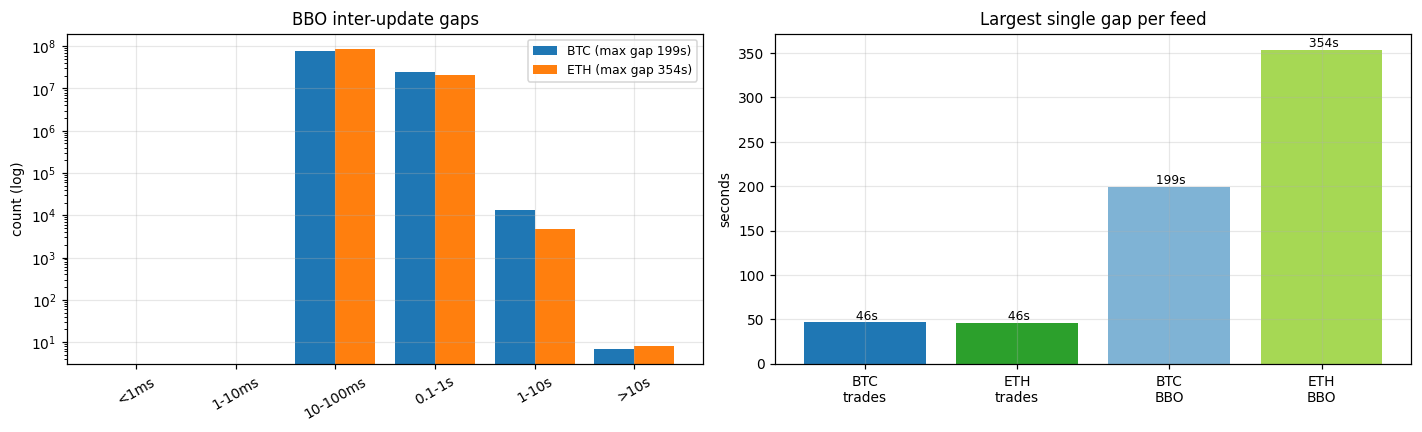

trade gaps >10s: {'btc': 13, 'eth': 4}


In [5]:
gh = pl.read_parquet(f"{OUT}/quirks_bbo_gap_hist.parquet")
order = ["0 <1ms", "1 1-10ms", "2 10-100ms", "3 0.1-1s", "4 1-10s", "5 >10s"]
labels = ["<1ms", "1-10ms", "10-100ms", "0.1-1s", "1-10s", ">10s"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(order))
for k, sym in enumerate(["btc", "eth"]):
    s = gh.filter(pl.col("symbol") == sym)
    counts = [s.filter(pl.col("bucket") == b)["c"].sum() for b in order]
    ax[0].bar(x + (k - 0.5) * 0.4, counts, 0.4, label=f"{sym.upper()} (max gap {Q['bbo'][sym]['max_gap_s']:.0f}s)")
ax[0].set_yscale("log"); ax[0].set_xticks(x); ax[0].set_xticklabels(labels, rotation=30)
ax[0].set(title="BBO inter-update gaps", ylabel="count (log)"); ax[0].legend(fontsize=8)

tb = [("BTC\ntrades", Q["trades"]["btc"]), ("ETH\ntrades", Q["trades"]["eth"]),
      ("BTC\nBBO", Q["bbo"]["btc"]), ("ETH\nBBO", Q["bbo"]["eth"])]
ax[1].bar([t[0] for t in tb], [t[1]["max_gap_s"] for t in tb],
          color=["#1f77b4", "#2ca02c", "#7fb3d5", "#a6d854"])
ax[1].set(title="Largest single gap per feed", ylabel="seconds")
for i, t in enumerate(tb):
    ax[1].text(i, t[1]["max_gap_s"], f" {t[1]['max_gap_s']:.0f}s", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()
print("trade gaps >10s:", {s: Q["trades"][s]["n_gaps_gt_10s"] for s in ["btc", "eth"]})

### 6 · Exchange 2 needs sort + dedupe · 7 · Clean books, fixed grids

Exchange 2 liquidations are non-monotonic with **3–4% duplicate timestamps** and a few fully
duplicated rows → sort and dedupe before merging (and apply +200 ms). Exchange 1 liquidations are
clean (0% dup). The order books are pristine: **no crossed, locked, or zero-size quotes**;
tick is \$0.1 (BTC) / \$0.01 (ETH), lot 0.001.

In [6]:
ql = Q["liquidations"]; qb = Q["bbo"]
print("Liquidation feeds:")
print(pl.DataFrame([{"feed": k, "dup_ts_%": round(v["dup_ts_pct"], 2),
                     "exact_dup_rows": v["exact_dup_rows"], "sell_%": round(v["sell_pct"], 1)}
                    for k, v in ql.items()]))
print("\nBBO integrity:")
print(pl.DataFrame([{"sym": k, "crossed": v["crossed"], "locked": v["locked"],
                     "zero_size": v["zero_size"], "tick": round(v["tick"], 4)} for k, v in qb.items()]))

Liquidation feeds:
shape: (4, 4)
┌────────────────┬──────────┬────────────────┬────────┐
│ feed           ┆ dup_ts_% ┆ exact_dup_rows ┆ sell_% │
│ ---            ┆ ---      ┆ ---            ┆ ---    │
│ str            ┆ f64      ┆ i64            ┆ f64    │
╞════════════════╪══════════╪════════════════╪════════╡
│ exchange_1_btc ┆ 0.0      ┆ 0              ┆ 56.2   │
│ exchange_1_eth ┆ 0.0      ┆ 0              ┆ 55.8   │
│ exchange_2_btc ┆ 4.33     ┆ 2              ┆ 67.3   │
│ exchange_2_eth ┆ 3.26     ┆ 4              ┆ 70.3   │
└────────────────┴──────────┴────────────────┴────────┘

BBO integrity:
shape: (2, 5)
┌─────┬─────────┬────────┬───────────┬──────┐
│ sym ┆ crossed ┆ locked ┆ zero_size ┆ tick │
│ --- ┆ ---     ┆ ---    ┆ ---       ┆ ---  │
│ str ┆ i64     ┆ i64    ┆ i64       ┆ f64  │
╞═════╪═════════╪════════╪═══════════╪══════╡
│ btc ┆ 0       ┆ 0      ┆ 0         ┆ 0.1  │
│ eth ┆ 0       ┆ 0      ┆ 0         ┆ 0.01 │
└─────┴─────────┴────────┴───────────┴──────┘


### 8 · Sell-side skew in a crash

Liquidations are sell-heavy (long liquidations), 56% on Exchange 1, 67% on Exchange 2 (BTC). The
sample period is a sustained decline: BTC traded from ~\$98k down to ~\$60k, with the heaviest
liquidation notional in the late-Jan / Feb stress (the validation leg).

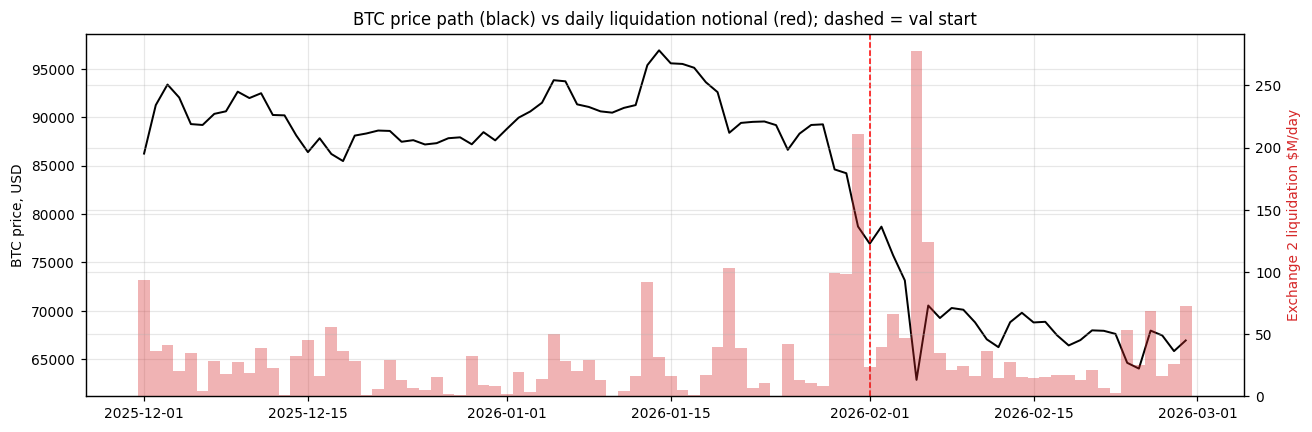

BTC price range: $59,800 – $97,932


In [7]:
pd_ = pl.read_parquet(f"{OUT}/quirks_price_daily.parquet").with_columns(
    date=pl.from_epoch("day_idx", time_unit="d").dt.date())
fig, ax1 = plt.subplots(figsize=(12, 4))
btc = pd_.filter(pl.col("symbol") == "btc").sort("date")
ax1.plot(btc["date"], btc["last_price"], color="black", lw=1.3, label="BTC last price")
ax1.set_ylabel("BTC price, USD"); ax1.axvline(__import__("datetime").date(2026, 2, 1), color="r", ls="--", lw=1)
ax2 = ax1.twinx()
lb = (liq("exchange_2", "btc").with_columns(
        day=pl.from_epoch("timestamp", time_unit="us").dt.date(),
        notional=pl.col("price") * pl.col("amount"))
     .group_by("day").agg(notl=pl.col("notional").sum()).sort("day"))
ax2.bar(lb["day"], lb["notl"] / 1e6, color="#d62728", alpha=0.35, width=1.0, label="Exchange 2 liq $M/day")
ax2.set_ylabel("Exchange 2 liquidation $M/day", color="#d62728")
ax1.set_title("BTC price path (black) vs daily liquidation notional (red); dashed = val start")
plt.tight_layout(); plt.show()
print(f"BTC price range: ${btc['lo'].min():,.0f} – ${btc['hi'].max():,.0f}")

### 9 · No funding-time clustering (a corrected non-finding) · 10 · Regime shift + opposite BTC/ETH

An earlier pass claimed ~2.3× clustering at funding, that was a **baseline error**. Being
"within ±60 s of any of the 3 daily funding times" covers 3·120 s / 86400 s = **0.417%** of the
day by chance, not 0.14%. The observed share is **0.21–0.32%, at or below uniform**, so there is
**no funding-time clustering**. The real cross-cutting risks stand: activity roughly doubles
train→val (§2), and full-data markout is **negative for BTC but positive
for ETH** on validation (§4).

In [8]:
UNIFORM = 3 * 120 / 86400 * 100
print(f"Funding clustering, observed vs uniform baseline {UNIFORM:.3f}% (>baseline ⇒ clustering):")
print(pl.DataFrame([{"feed": k, "within_60s_%": round(v["funding_within60_pct"], 3),
                     "vs_uniform_x": round(v["funding_within60_pct"] / UNIFORM, 2),
                     "weekend_%": round(v["weekend_pct"], 1)} for k, v in Q["liquidations"].items()]))

Funding clustering, observed vs uniform baseline 0.417% (>baseline ⇒ clustering):
shape: (4, 4)
┌────────────────┬──────────────┬──────────────┬───────────┐
│ feed           ┆ within_60s_% ┆ vs_uniform_x ┆ weekend_% │
│ ---            ┆ ---          ┆ ---          ┆ ---       │
│ str            ┆ f64          ┆ f64          ┆ f64       │
╞════════════════╪══════════════╪══════════════╪═══════════╡
│ exchange_1_btc ┆ 0.333        ┆ 0.8          ┆ 25.7      │
│ exchange_1_eth ┆ 0.295        ┆ 0.71         ┆ 25.3      │
│ exchange_2_btc ┆ 0.326        ┆ 0.78         ┆ 26.9      │
│ exchange_2_eth ┆ 0.22         ┆ 0.53         ┆ 28.0      │
└────────────────┴──────────────┴──────────────┴───────────┘


### Takeaways for the signal

- **Trust Exchange 2 for liquidation intensity**, not Exchange 1 (throttled). Apply +200 ms, sort, dedupe.
- **Aggregate trades per ms** (sweeps); don't double-count sub-fills.
- **Guard markout against stale mids** (rare multi-minute BBO gaps) and **trade-feed outages**
  (treat ~tens-of-seconds gaps as missing).
- **Everything is ms-resolution**, align on ms.
- **Validate per symbol and per regime**, Feb is a different, more stressed world, and BTC/ETH
  diverge there.

## 2 · Liquidation structure and toxicity drivers

Goal: characterise the **liquidation
process** that the trade-filtering signal is built on. Everything here uses only the four
**liquidation** tables (each ≤ 2.4 MB), the multi-GB trades/BBO tables enter only in §4 (via
cached artifacts from the streamed markout), so this section is memory-safe and runs in seconds.

**Data:** Exchange 1 & Exchange 2 forced liquidations for `btcusdt` / `ethusdt`, Dec 2025 – Feb 2026.
`timestamp` = int64 **microseconds** UTC. `side` = side of the liquidation **order**
(`buy` ⇒ a short is force-bought ⇒ upward pressure; `sell` ⇒ a long is force-sold ⇒ downward).

**Conventions used throughout**
- Train = `2025-12-01 → 2026-01-31`, Validation = `2026-02-01 → 2026-02-28`.
- **Exchange 2 events are shifted +200 ms before any cross-exchange merge** (network latency, per spec).

In [9]:
import datetime as dt
import matplotlib.dates as mdates
pl.Config.set_tbl_rows(20)

FILES = {
    ("exchange_1", "btc"): f"{DATA}/exchange_1_liquidations/perp_btcusdt.parquet",
    ("exchange_1", "eth"): f"{DATA}/exchange_1_liquidations/perp_ethusdt.parquet",
    ("exchange_2",   "btc"): f"{DATA}/exchange_2_liquidations/btcusdt.parquet",
    ("exchange_2",   "eth"): f"{DATA}/exchange_2_liquidations/ethusdt.parquet",
}
EXSYM_COLORS = {"exchange_1_btc": "#1f77b4", "exchange_1_eth": "#9ecae1",
                "exchange_2_btc": "#d62728", "exchange_2_eth": "#ff9896"}
SYM_COLORS = {"btc": "#1f77b4", "eth": "#2ca02c"}

VAL_START_US = 1_769_904_000_000_000
VAL_START_DATE = dt.date(2026, 2, 1)
EXCHANGE_2_LAG_US = 200_000
N_TRAIN_DAYS, N_VAL_DAYS = 62, 28

def load_liq(ex, sym):
    return (pl.read_parquet(FILES[(ex, sym)])
             .with_columns(notional=pl.col("price") * pl.col("amount")))

def combined_stream(sym):
    bn = load_liq("exchange_1", sym).with_columns(ex=pl.lit("exchange_1"))
    bb = (load_liq("exchange_2", sym)
           .with_columns((pl.col("timestamp") + EXCHANGE_2_LAG_US).alias("timestamp"),
                          ex=pl.lit("exchange_2")))
    return pl.concat([bn, bb]).sort("timestamp")

def to_date(col="timestamp"):
    return pl.from_epoch(pl.col(col), time_unit="us").dt.date()

### 2.1 · Inventory & data quality

One pass over every table: row counts, time coverage, monotonicity, duplicate timestamps,
nulls, non-positive prices/amounts, side balance and notional summary.

In [10]:
rows = []
for (ex, sym), path in FILES.items():
    d = load_liq(ex, sym)
    ts = d["timestamp"]
    rows.append({
        "table": f"{ex}_{sym}",
        "rows": d.height,
        "t_min": dt.datetime.fromtimestamp(ts.min()/1e6, dt.timezone.utc).strftime("%Y-%m-%d %H:%M"),
        "t_max": dt.datetime.fromtimestamp(ts.max()/1e6, dt.timezone.utc).strftime("%Y-%m-%d %H:%M"),
        "monotonic": ts.is_sorted(),
        "dup_ts_%": round(100*ts.is_duplicated().sum()/d.height, 2),
        "nulls": int(d.null_count().to_numpy().sum()),
        "nonpos": int((d["price"] <= 0).sum() + (d["amount"] <= 0).sum()),
        "buy_%": round(100*(d["side"] == "buy").mean(), 1),
        "notl_med": round(d["notional"].median()),
        "notl_p99": round(d["notional"].quantile(0.99)),
        "notl_sum_$B": round(d["notional"].sum()/1e9, 3),
        "train": int((ts < VAL_START_US).sum()),
        "val": int((ts >= VAL_START_US).sum()),
    })
quality = pl.DataFrame(rows)
quality

table,rows,t_min,t_max,monotonic,dup_ts_%,nulls,nonpos,buy_%,notl_med,notl_p99,notl_sum_$B,train,val
str,i64,str,str,bool,f64,i64,i64,f64,i64,i64,f64,i64,i64
"""exchange_1_btc""",114255,"""2025-12-01 00:00""","""2026-02-28 23:59""",true,0.0,0,0,43.8,1116,163353,1.292,63660,50595
"""exchange_1_eth""",131769,"""2025-12-01 00:00""","""2026-02-28 23:49""",true,0.0,0,0,44.2,728,148860,1.309,76634,55135
"""exchange_2_btc""",228655,"""2025-12-01 00:00""","""2026-02-28 23:58""",false,4.33,0,0,32.7,1118,200303,2.913,124465,104190
"""exchange_2_eth""",160214,"""2025-12-01 00:00""","""2026-02-28 23:34""",false,3.26,0,0,29.7,912,179385,1.646,97116,63098


- All tables are **null-free**, no non-positive prices/amounts → no hard data-quality blocker.
- **Exchange 1** liquidations are monotonic with **0% duplicate timestamps**; **Exchange 2** is
  *not* monotonic and has **3–4% duplicate timestamps**, so it must be sorted before use. Those
  duplicate timestamps are distinct events (keep them); only the handful of fully exact-duplicate
  rows should be dropped (next cell).
- Strong **sell-side skew** everywhere (buy_% well below 50, Exchange 2 BTC ≈ 33% buys): the sample
  period is dominated by long liquidations (downward forced selling).
- Exchange 2 reports more events than Exchange 1 (Exchange 1 aggregates micro-fills); the gap is large on
  BTC and smaller on ETH.

In [11]:
bb = load_liq("exchange_2", "btc")
dups = bb.filter(bb["timestamp"].is_duplicated()).sort("timestamp")
print(f"Exchange 2 BTC: {bb.height:,} rows, {bb['timestamp'].is_duplicated().sum():,} share a timestamp "
      f"with ≥1 other row ({100*bb['timestamp'].is_duplicated().mean():.2f}%).")
print("Example collision (same µs, distinct fills, keep all, just sort):")
print(dups.head(4))
bb_sorted = bb.sort("timestamp", maintain_order=True)
print("monotonic after sort:", bb_sorted["timestamp"].is_sorted())

Exchange 2 BTC: 228,655 rows, 9,894 share a timestamp with ≥1 other row (4.33%).
Example collision (same µs, distinct fills, keep all, just sort):
shape: (4, 6)
┌──────────────────┬─────────┬──────┬─────────┬────────┬───────────┐
│ timestamp        ┆ ticker  ┆ side ┆ price   ┆ amount ┆ notional  │
│ ---              ┆ ---     ┆ ---  ┆ ---     ┆ ---    ┆ ---       │
│ i64              ┆ str     ┆ str  ┆ f64     ┆ f64    ┆ f64       │
╞══════════════════╪═════════╪══════╪═════════╪════════╪═══════════╡
│ 1764547446416000 ┆ btcusdt ┆ sell ┆ 89613.4 ┆ 0.008  ┆ 716.9072  │
│ 1764547446416000 ┆ btcusdt ┆ sell ┆ 89598.0 ┆ 0.003  ┆ 268.794   │
│ 1764547446648000 ┆ btcusdt ┆ sell ┆ 89437.8 ┆ 0.012  ┆ 1073.2536 │
│ 1764547446648000 ┆ btcusdt ┆ sell ┆ 89614.3 ┆ 0.034  ┆ 3046.8862 │
└──────────────────┴─────────┴──────┴─────────┴────────┴───────────┘
monotonic after sort: True


### 2.2 · Notional magnitude & heavy tails

Per-event notional spans many orders of magnitude. The survival curve `P(notional > x)` on
log-log axes shows a heavy (near power-law) tail, a handful of events dwarf the median.
This is the quantitative reason a **single event's size is a weak signal**: the distribution
is so heavy that one print tells you little; cumulative windowed notional is more informative.

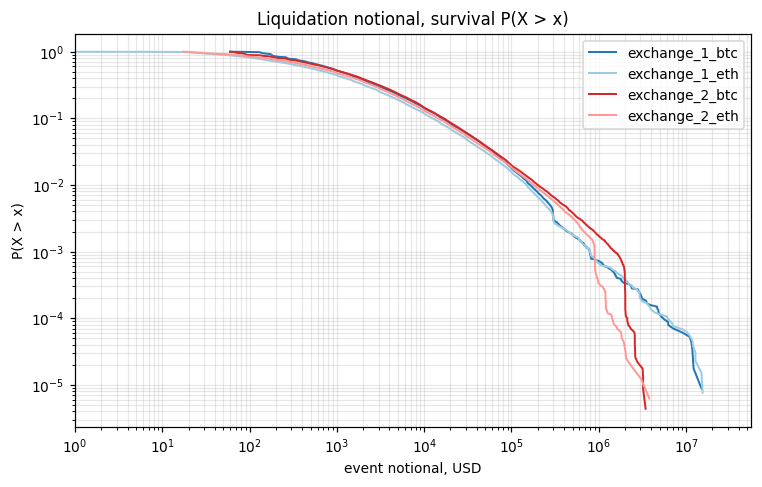

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for (ex, sym), path in FILES.items():
    x = np.sort(load_liq(ex, sym)["notional"].to_numpy())
    x = x[x > 0]
    surv = 1.0 - np.arange(len(x)) / len(x)
    ax.loglog(x, surv, lw=1.3, label=f"{ex}_{sym}", color=EXSYM_COLORS[f"{ex}_{sym}"])
ax.set_xlim(left=1)
ax.set(title="Liquidation notional, survival P(X > x)", xlabel="event notional, USD", ylabel="P(X > x)")
ax.legend(); ax.grid(which="both", alpha=0.3)
plt.tight_layout(); plt.show()

### 2.3 · Activity over time: the train→validation regime shift

Daily event count and notional per exchange/symbol. The dashed line is the train/val boundary
(2026-02-01). February (validation) is visibly a **more stressed regime**: more and larger
liquidations. This matches the team's headline finding and is the main out-of-sample risk,
a filter tuned on the calmer train period must survive the busier val period.

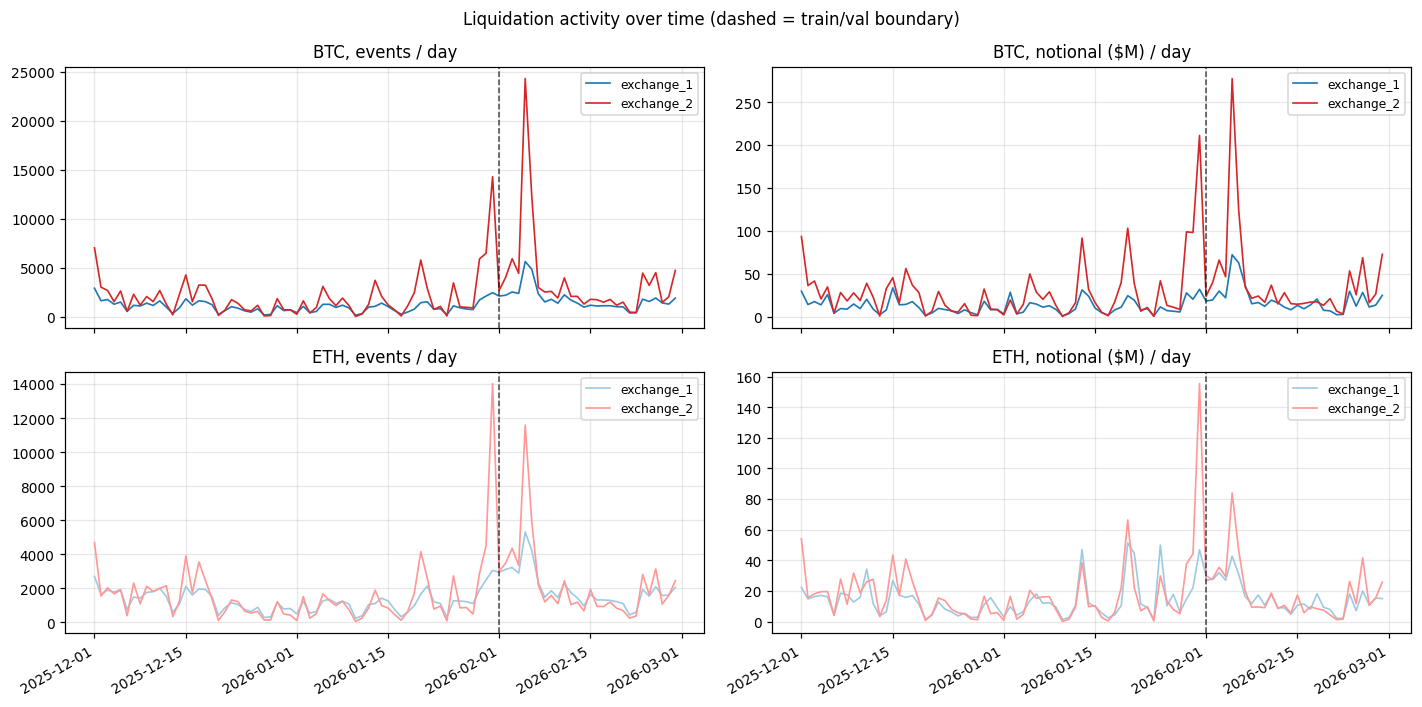

table,ev/day train,ev/day val,ev x,$M/day train,$M/day val,$ x
str,i64,i64,f64,f64,f64,f64
"""exchange_1_btc""",1027,1807,1.76,11.9,19.8,1.66
"""exchange_1_eth""",1236,1969,1.59,14.0,15.8,1.13
"""exchange_2_btc""",2008,3721,1.85,28.6,40.7,1.42
"""exchange_2_eth""",1566,2254,1.44,18.0,18.9,1.05


In [13]:
def daily(ex, sym):
    return (load_liq(ex, sym)
           .with_columns(day=to_date())
           .group_by("day").agg(n=pl.len(), notional=pl.col("notional").sum())
           .sort("day"))

daily_data = {(ex, sym): daily(ex, sym) for ex, sym in FILES}

fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True)
vb = mdates.date2num(VAL_START_DATE)
for r, sym in enumerate(["btc", "eth"]):
    for ex in ["exchange_1", "exchange_2"]:
        d = daily_data[(ex, sym)]
        x = d["day"].to_list()
        axes[r, 0].plot(x, d["n"], lw=1.1, label=ex, color=EXSYM_COLORS[f"{ex}_{sym}"])
        axes[r, 1].plot(x, d["notional"]/1e6, lw=1.1, label=ex, color=EXSYM_COLORS[f"{ex}_{sym}"])
    for c, t in enumerate(["events / day", "notional ($M) / day"]):
        axes[r, c].axvline(vb, color="k", ls="--", lw=1, alpha=0.7)
        axes[r, c].set_title(f"{sym.upper()}, {t}"); axes[r, c].legend(fontsize=8)
fig.suptitle("Liquidation activity over time (dashed = train/val boundary)")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

rs = []
for (ex, sym), d in daily_data.items():
    tr = d.filter(pl.col("day") < VAL_START_DATE); va = d.filter(pl.col("day") >= VAL_START_DATE)
    rs.append({"table": f"{ex}_{sym}",
               "ev/day train": round(tr["n"].mean()), "ev/day val": round(va["n"].mean()),
               "ev x": round(va["n"].mean()/tr["n"].mean(), 2),
               "$M/day train": round(tr["notional"].mean()/1e6, 1), "$M/day val": round(va["notional"].mean()/1e6, 1),
               "$ x": round(va["notional"].mean()/tr["notional"].mean(), 2)})
pl.DataFrame(rs)

#### Intraday seasonality (hour of day, UTC)

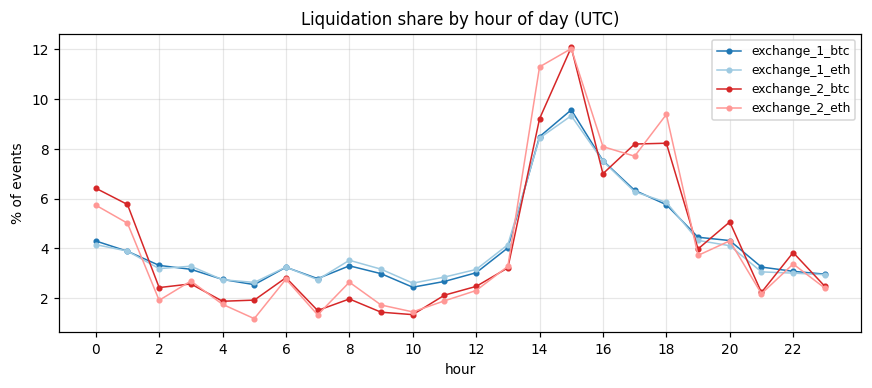

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for (ex, sym) in FILES:
    h = (load_liq(ex, sym)
        .with_columns(hour=pl.from_epoch("timestamp", time_unit="us").dt.hour())
        .group_by("hour").agg(n=pl.len()).sort("hour"))
    ax.plot(h["hour"], h["n"]/h["n"].sum()*100, marker=".", lw=1, label=f"{ex}_{sym}",
            color=EXSYM_COLORS[f"{ex}_{sym}"])
ax.set(title="Liquidation share by hour of day (UTC)", xlabel="hour", ylabel="% of events", xticks=range(0,24,2))
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 2.4 · Burstiness: liquidations are cascades, not Poisson

If liquidations were a Poisson process, inter-arrival gaps would be exponential and the
coefficient of variation `CV = std/mean` would be ≈ 1. Instead CV ≫ 1 and the empirical
survival sits far below the matched exponential: a large mass of sub-second gaps (events
arriving in bursts) plus a fat tail of long quiet gaps. Note Exchange 1 has **no** sub-0.5s
gaps, it aggregates fills to ~1s buckets, whereas Exchange 2 is true per-event ms precision.

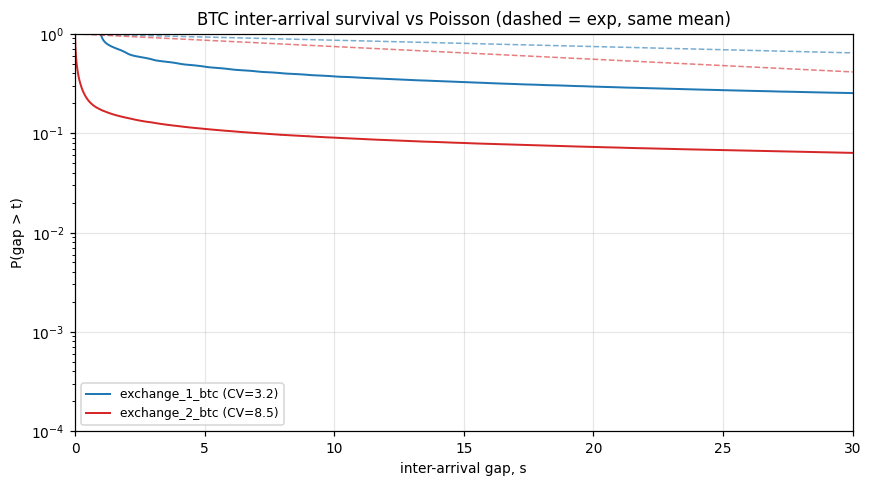

table,mean_iat_s,median_iat_s,CV,frac_<0.5s_%
str,f64,f64,f64,f64
"""exchange_1_btc""",68.06,4.042,3.16,0.0
"""exchange_1_eth""",59.01,4.247,2.99,0.0
"""exchange_2_btc""",34.01,0.059,8.48,78.9
"""exchange_2_eth""",48.53,0.081,6.84,73.4


In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
rows = []
for (ex, sym) in FILES:
    ts = load_liq(ex, sym)["timestamp"].sort().to_numpy()
    gaps = np.diff(ts) / 1e6
    gaps = gaps[gaps >= 0]
    cv = gaps.std() / gaps.mean()
    rows.append({"table": f"{ex}_{sym}", "mean_iat_s": round(gaps.mean(), 2),
                 "median_iat_s": round(float(np.median(gaps)), 3), "CV": round(cv, 2),
                 "frac_<0.5s_%": round((gaps < 0.5).mean()*100, 1)})
    if sym == "btc":
        x = np.sort(gaps[gaps > 0]); surv = 1 - np.arange(len(x))/len(x)
        ax.semilogy(x, surv, lw=1.3, color=EXSYM_COLORS[f"{ex}_{sym}"], label=f"{ex}_{sym} (CV={cv:.1f})")
        ax.semilogy(x, np.exp(-x/gaps.mean()), ls="--", lw=1, color=EXSYM_COLORS[f"{ex}_{sym}"], alpha=0.6)
ax.set(xlim=(0, 30), ylim=(1e-4, 1), title="BTC inter-arrival survival vs Poisson (dashed = exp, same mean)",
       xlabel="inter-arrival gap, s", ylabel="P(gap > t)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
pl.DataFrame(rows)

### 2.5 · Clusters & cascades (cross-exchange, Exchange 2 +200 ms)

Group the **combined** Exchange 1+Exchange 2 stream into clusters separated by gaps > **500 ms**.
A **cascade** = cluster with **≥ 5 events, ≥ \$1M total, ≤ 30 s** duration. Cluster *total
notional* and *size* (not single-event amplitude) are the features the team found most
predictive. Clusters/day rises ~1.6–1.7× in validation (the §2.3 regime shift, at the
cluster level).

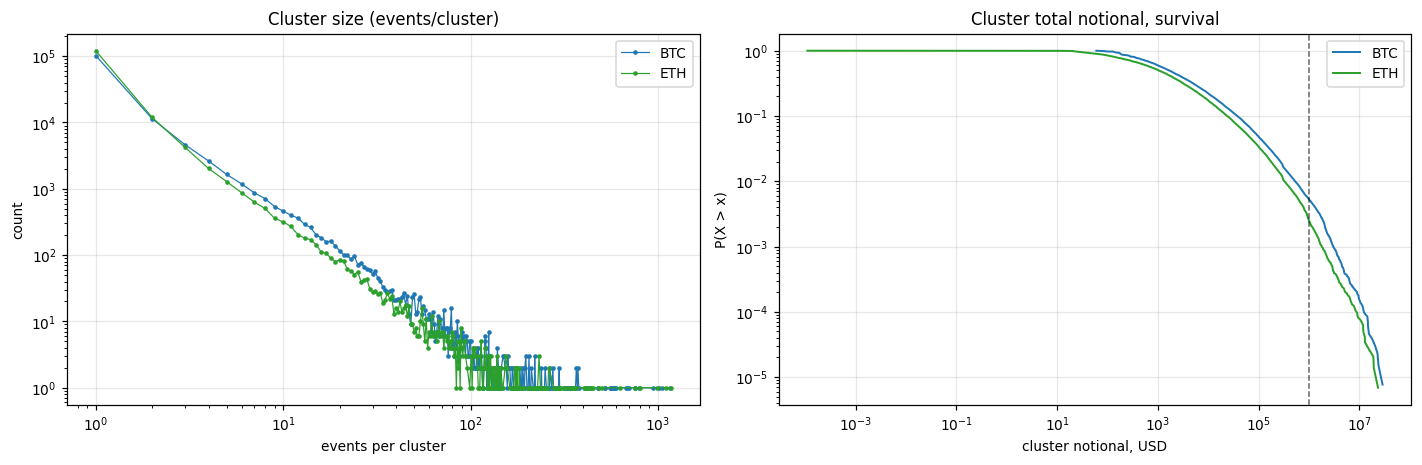

sym,clusters,cascades,clust/day train,clust/day val,clust x,multi-ex% train,multi-ex% val,size p99,size max
str,i64,i64,i64,i64,f64,f64,f64,i64,i64
"""BTC""",130465,563,1178,2050,1.74,17.0,19.3,29,1161
"""ETH""",145683,283,1362,2186,1.6,14.6,15.5,18,1173


In [16]:
def build_clusters(sym, gap_us=500_000):
    df = combined_stream(sym)
    new = (df["timestamp"] - df["timestamp"].shift(1)).fill_null(gap_us + 1) > gap_us
    return (df.with_columns(cid=new.cum_sum())
             .group_by("cid")
             .agg(t0=pl.col("timestamp").min(), t1=pl.col("timestamp").max(), n=pl.len(),
                   notional=pl.col("notional").sum(),
                   n_exchange_2=(pl.col("ex") == "exchange_2").sum(), n_exchange_1=(pl.col("ex") == "exchange_1").sum(),
                   buy_notl=pl.when(pl.col("side") == "buy").then("notional").otherwise(0).sum(),
                   sell_notl=pl.when(pl.col("side") == "sell").then("notional").otherwise(0).sum())
             .with_columns(dur_s=(pl.col("t1") - pl.col("t0"))/1e6,
                            multi_ex=(pl.col("n_exchange_2") > 0) & (pl.col("n_exchange_1") > 0),
                            day=to_date("t0"),
                            side_imb=(pl.col("buy_notl") - pl.col("sell_notl"))/(pl.col("buy_notl") + pl.col("sell_notl"))))

clusters = {sym: build_clusters(sym) for sym in ["btc", "eth"]}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
summ = []
for sym in ["btc", "eth"]:
    cl = clusters[sym]
    cas = cl.filter((pl.col("n") >= 5) & (pl.col("notional") >= 1e6) & (pl.col("dur_s") <= 30))
    tr, va = cl.filter(pl.col("day") < VAL_START_DATE), cl.filter(pl.col("day") >= VAL_START_DATE)
    summ.append({"sym": sym.upper(), "clusters": cl.height, "cascades": cas.height,
                 "clust/day train": round(tr.height/N_TRAIN_DAYS), "clust/day val": round(va.height/N_VAL_DAYS),
                 "clust x": round((va.height/N_VAL_DAYS)/(tr.height/N_TRAIN_DAYS), 2),
                 "multi-ex% train": round(tr["multi_ex"].mean()*100, 1), "multi-ex% val": round(va["multi_ex"].mean()*100, 1),
                 "size p99": int(cl["n"].quantile(0.99)), "size max": int(cl["n"].max())})
    sizes = cl["n"].to_numpy()
    vals, counts = np.unique(sizes, return_counts=True)
    axes[0].loglog(vals, counts, marker=".", ms=4, lw=0.8, label=sym.upper(), color=SYM_COLORS[sym])
    nn = np.sort(cl["notional"].to_numpy()); surv = 1 - np.arange(len(nn))/len(nn)
    axes[1].loglog(nn, surv, lw=1.3, label=sym.upper(), color=SYM_COLORS[sym])
axes[0].set(title="Cluster size (events/cluster)", xlabel="events per cluster", ylabel="count"); axes[0].legend()
axes[1].axvline(1e6, color="k", ls="--", lw=1, alpha=0.6)
axes[1].set(title="Cluster total notional, survival", xlabel="cluster notional, USD", ylabel="P(X > x)"); axes[1].legend()
plt.tight_layout(); plt.show()
pl.DataFrame(summ)

### 2.6 · Cross-exchange overlap: does Exchange 2 lead Exchange 1?

For each event, is there an event on the *other* exchange within **±1 s** (Exchange 2 already
shifted +200 ms)? This splits events into **exchange_2-only / exchange_1-only / both**. The team's
event-study found Exchange 2-only events still move the Exchange 1 mid (Exchange 2 leads, Exchange 1 confirms);
here we just quantify how often each regime occurs and how it shifts train→val.

In [17]:
def overlap_shares(sym, win_us=1_000_000):
    df = combined_stream(sym)
    bn = df.filter(pl.col("ex") == "exchange_1")["timestamp"].to_numpy()
    bb = df.filter(pl.col("ex") == "exchange_2")["timestamp"].to_numpy()
    def has_near(a, b):
        if len(b) == 0: return np.zeros(len(a), bool)
        lo = np.searchsorted(b, a - win_us, "left"); hi = np.searchsorted(b, a + win_us, "right")
        return hi > lo
    out = []
    for label, ts, near in [("exchange_2", bb, has_near(bb, bn)), ("exchange_1", bn, has_near(bn, bb))]:
        for split, m in [("train", ts < VAL_START_US), ("val", ts >= VAL_START_US)]:
            n = m.sum()
            out.append({"sym": sym.upper(), "anchor": label, "split": split,
                        "events": int(n), "has_other_±1s_%": round(100*near[m].mean(), 1)})
    return out

rows = []
for sym in ["btc", "eth"]:
    rows += overlap_shares(sym)
pl.DataFrame(rows)

sym,anchor,split,events,has_other_±1s_%
str,str,str,i64,f64
"""BTC""","""exchange_2""","""train""",124465,88.9
"""BTC""","""exchange_2""","""val""",104190,89.7
"""BTC""","""exchange_1""","""train""",63660,34.7
"""BTC""","""exchange_1""","""val""",50595,38.5
"""ETH""","""exchange_2""","""train""",97116,89.9
"""ETH""","""exchange_2""","""val""",63098,88.9
"""ETH""","""exchange_1""","""train""",76634,28.5
"""ETH""","""exchange_1""","""val""",55135,30.6


### 2.7 · Directional pressure: net liquidation imbalance over time

Daily **net liquidation notional** = buy-side − sell-side (buy ⇒ upward forcing, sell ⇒
downward). Persistent negative net pressure = long liquidations dominating (falling regime).
This is the raw material for a directional/`dominant_side` feature.

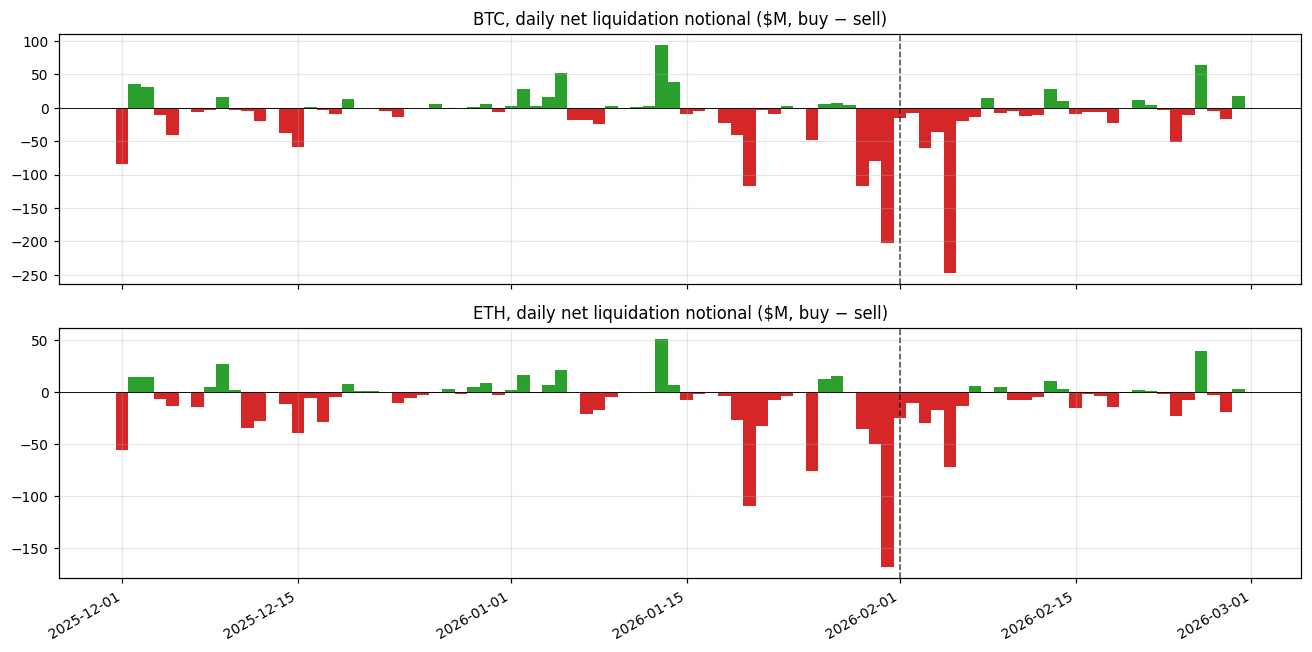

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, sym in zip(axes, ["btc", "eth"]):
    d = (combined_stream(sym)
        .with_columns(day=to_date(),
                       signed=pl.when(pl.col("side") == "buy").then(pl.col("notional")).otherwise(-pl.col("notional")))
        .group_by("day").agg(net=pl.col("signed").sum()).sort("day"))
    x = d["day"].to_list(); net = (d["net"]/1e6).to_numpy()
    ax.bar(x, net, color=np.where(net >= 0, "#2ca02c", "#d62728"), width=1.0)
    ax.axvline(mdates.date2num(VAL_START_DATE), color="k", ls="--", lw=1, alpha=0.7)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{sym.upper()}, daily net liquidation notional ($M, buy − sell)")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### Liquidation-structure takeaways

**Confirmed on this data (liquidation tables only):**
1. **Clean data**, but **Exchange 2 must be sorted** (non-monotonic, 3–4% duplicate µs timestamps that
   are distinct events; drop only the few exact-duplicate rows).
2. **Heavy-tailed notional** → single-event size is a weak signal; prefer windowed cumulative.
3. **Strong train→val regime shift**: events/day ×1.4–1.85, clusters/day ≈ ×1.6–1.7,
   bigger notional, the dominant out-of-sample risk.
4. **Bursty / non-Poisson** arrivals (CV 3–8); Exchange 1 aggregates to ~1s, Exchange 2 is ms-precise.
5. **Cascade structure** reproduces the team's counts (BTC ≈ 130k clusters, 563 cascades);
   cluster size & total notional are the natural signal features.
6. **Sell-side / downward** liquidation pressure dominates the period.

The maker-markout, event study, adverse selection, and feature-IC analyses (which need the
multi-GB trades/BBO tables) follow in §3–§4.

## 3 · Microstructure

Beyond data-quality: how order flow and price actually behave, and what the liquidation
`price` field really is. Evidence cached by `python eda_compute.py micro` → `eda_results/micro_*`.

| Finding | Number | Implication |
|---|---|---|
| **Queue imbalance dominates the short horizon** | IC(imbalance → next-1s mid) = **+0.385**, 0.26 @5s, 0.11 @30s (verified not look-ahead) | the BBO-imbalance signal leads at the seconds horizon; liquidation features (IC ~0.01) act on the 30–300s toxic window, different signals, different horizons. (microprice ≡ imbalance here, ρ=0.999; it's an *association*, not a tested tradable alpha) |
| **Order flow has long memory** | sign ACF 0.25→0.08 over lags 1–50 | trades are persistent (Lillo–Farmer). The calm-vs-stress gap (0.25 → 0.48 at lag-1) is **only 2 hand-picked windows, suggestive, not a regime result** |
| **Momentum, not bid-ask bounce, at ms scale** | trade-price 1-step return autocorr **+0.15 (calm)** | persistent flow overpowers bounce; short-horizon mid trends |
| **Exchange 1 liquidation price sits a stable ~0.39% off mid** | \|offset\| ≈ **39 bps**, stable across BTC/ETH and train/val (p5–p95 ≈ 32–42 bps) | the liq `price` is a reference/limit-like price (**likely** bankruptcy/margin, inferred, not proven), **not a fill**, measure impact against the book mid at the event time |
| **A liquidation print LAGS the move** | top-decile Exchange 2: mid already moved **~7 bps** in the liq direction in the 2 s *before* the print; only **~+0.7 bps** after, then reverts | the print is the *consequence* of the move, not a forward trigger, chasing it buys the top of the cascade; use windowed cascade *intensity* (a state), not the single print as a trigger |

In [19]:
acf = pl.read_parquet(f"{OUT}/micro_orderflow_acf.parquet")
ic = pl.read_parquet(f"{OUT}/micro_imbalance_ic.parquet")
off = pl.read_parquet(f"{OUT}/micro_liq_offset.parquet")
ret = pl.read_parquet(f"{OUT}/micro_return_acf.parquet")
ll = pl.read_parquet(f"{OUT}/micro_leadlag.parquet")

### 3.1 · Queue imbalance / microprice, the dominant short-horizon predictor

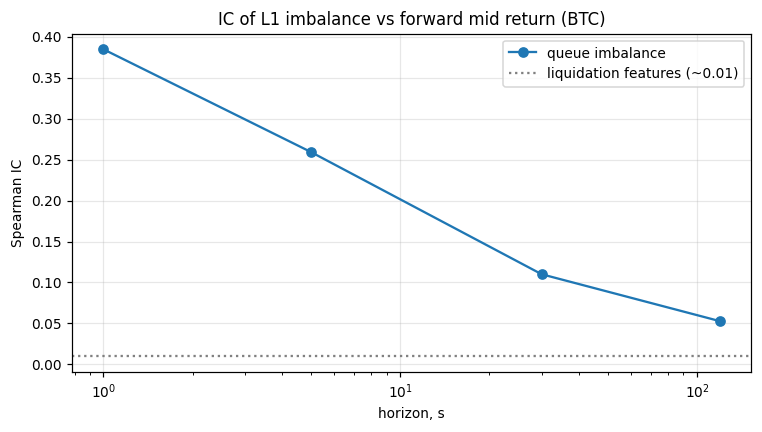

shape: (4, 3)
┌───────────┬──────────────┬───────────────┐
│ horizon_s ┆ ic_imbalance ┆ ic_microprice │
│ ---       ┆ ---          ┆ ---           │
│ i64       ┆ f64          ┆ f64           │
╞═══════════╪══════════════╪═══════════════╡
│ 1         ┆ 0.384693     ┆ 0.384197      │
│ 5         ┆ 0.259334     ┆ 0.258817      │
│ 30        ┆ 0.110037     ┆ 0.10981       │
│ 120       ┆ 0.05265      ┆ 0.052537      │
└───────────┴──────────────┴───────────────┘


In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ic["horizon_s"], ic["ic_imbalance"], marker="o", lw=1.5, label="queue imbalance")
ax.axhline(0.01, color="grey", ls=":", label="liquidation features (~0.01)")
ax.set(title="IC of L1 imbalance vs forward mid return (BTC)", xlabel="horizon, s", ylabel="Spearman IC")
ax.set_xscale("log"); ax.legend(); plt.tight_layout(); plt.show()
print(ic)

### 3.2 · Order flow has long memory

Slowly-decaying sign autocorrelation = persistent flow (Lillo–Farmer). The two windows below
(calm vs the crash day) hint the persistence rises in stress, but **n=2 hand-picked windows is
only suggestive**, a real regime claim needs a rolling-window distribution.

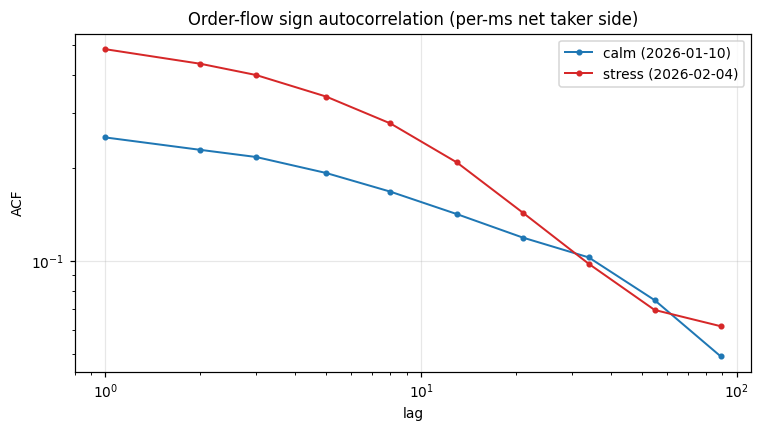

shape: (2, 3)
┌─────────────────────┬─────────────┬───────────────┐
│ window              ┆ series      ┆ lag1_autocorr │
│ ---                 ┆ ---         ┆ ---           │
│ str                 ┆ str         ┆ f64           │
╞═════════════════════╪═════════════╪═══════════════╡
│ calm (2026-01-10)   ┆ trade_price ┆ 0.153369      │
│ stress (2026-02-04) ┆ trade_price ┆ 0.089126      │
└─────────────────────┴─────────────┴───────────────┘


In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
for w, c in [("calm (2026-01-10)", "#1f77b4"), ("stress (2026-02-04)", "#d62728")]:
    s = acf.filter(pl.col("window") == w).sort("lag")
    ax.plot(s["lag"], s["acf"], marker=".", lw=1.3, color=c, label=w)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set(title="Order-flow sign autocorrelation (per-ms net taker side)", xlabel="lag", ylabel="ACF")
ax.legend(); plt.tight_layout(); plt.show()
print(ret)

### 3.3 · The Exchange 1 liquidation price sits a stable ~0.39% off the mid (not a fill)

The offset is a robustly-measured fact (median ≈ ±39 bps, stable across side, symbol and
train/val). Its *cause*, a bankruptcy/maintenance-margin reference price, is a reasonable
inference, not proven here; the operational point is solid either way: don't treat the liq
`price` as a trade price.

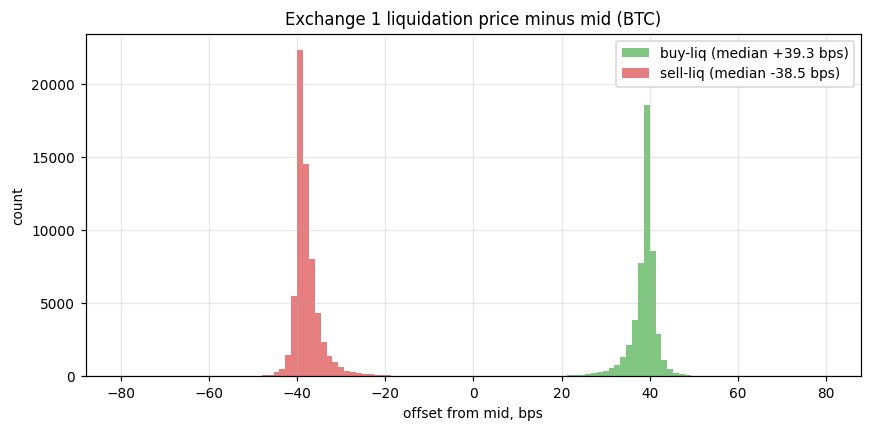

shape: (4, 4)
┌────────┬──────┬────────────┬─────────┐
│ symbol ┆ side ┆ median_bps ┆ std_bps │
│ ---    ┆ ---  ┆ ---        ┆ ---     │
│ str    ┆ str  ┆ f64        ┆ f64     │
╞════════╪══════╪════════════╪═════════╡
│ btc    ┆ buy  ┆ 39.3       ┆ 5.8     │
│ btc    ┆ sell ┆ -38.5      ┆ 39.5    │
│ eth    ┆ buy  ┆ 39.1       ┆ 49.4    │
│ eth    ┆ sell ┆ -38.2      ┆ 34.4    │
└────────┴──────┴────────────┴─────────┘


In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
btc = off.filter(pl.col("symbol") == "btc")
for side, c in [("buy", "#2ca02c"), ("sell", "#d62728")]:
    v = btc.filter(pl.col("side") == side)["offset_bps"].to_numpy()
    ax.hist(np.clip(v, -80, 80), bins=120, alpha=0.6, color=c, label=f"{side}-liq (median {np.median(v):+.1f} bps)")
ax.set(title="Exchange 1 liquidation price minus mid (BTC)", xlabel="offset from mid, bps", ylabel="count")
ax.legend(); plt.tight_layout(); plt.show()
print(off.group_by("symbol", "side").agg(median_bps=pl.col("offset_bps").median().round(1),
                                         std_bps=pl.col("offset_bps").std().round(1)).sort("symbol", "side"))

### 3.4 · A liquidation print *lags* the price move

Signed Exchange 1-mid impulse response vs lag relative to a liquidation print (real time, top-decile
by notional). The move is **mostly already done before the print** (pre-event drift), with only a
small continuation after that then reverts, the print is the consequence of the cascade, not a
forward trigger. (Exchange 1 is flatter, its 1 s-throttled print is less tied to a precise instant.)

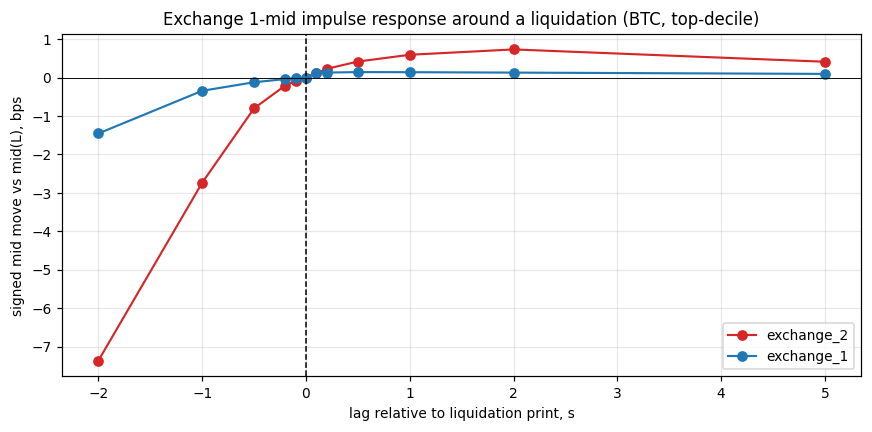

shape: (2, 13)
┌────────────┬───────────┬───────────┬───────────┬───┬──────────┬──────────┬──────────┬──────────┐
│ exchange   ┆ -2.0      ┆ -1.0      ┆ -0.5      ┆ … ┆ 0.5      ┆ 1.0      ┆ 2.0      ┆ 5.0      │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str        ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪══════════╪══════════╪══════════╡
│ exchange_2 ┆ -7.367797 ┆ -2.737601 ┆ -0.800811 ┆ … ┆ 0.417038 ┆ 0.593671 ┆ 0.732625 ┆ 0.411804 │
│ exchange_1 ┆ -1.455464 ┆ -0.344116 ┆ -0.12173  ┆ … ┆ 0.142819 ┆ 0.140064 ┆ 0.129455 ┆ 0.095505 │
└────────────┴───────────┴───────────┴───────────┴───┴──────────┴──────────┴──────────┴──────────┘


In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
for ex, c in [("exchange_2", "#d62728"), ("exchange_1", "#1f77b4")]:
    s = ll.filter((ll["exchange"] == ex) & (ll["bucket"] == "top_decile")).sort("lag_s")
    ax.plot(s["lag_s"], s["response_bps"], marker="o", lw=1.4, color=c, label=ex)
ax.axvline(0, color="k", lw=1, ls="--"); ax.axhline(0, color="k", lw=0.6)
ax.set(title="Exchange 1-mid impulse response around a liquidation (BTC, top-decile)",
       xlabel="lag relative to liquidation print, s", ylabel="signed mid move vs mid(L), bps")
ax.legend(); plt.tight_layout(); plt.show()
print(ll.filter(ll["bucket"] == "top_decile").pivot(values="response_bps", index="exchange", on="lag_s"))

### Takeaways

- **Two-speed signal:** queue imbalance for the next seconds (IC ~0.39, an association to
  exploit via quote-skew, not a verified post-cost alpha), liquidation flow for the 30–300 s
  toxic window. A maker quote should skew on imbalance *and* back off on liquidation pressure.
- **Long-memory, trending flow** is the adverse-selection mechanism (the stress amplification is
  suggestive, from 2 windows only).
- **Never use the liquidation `price` as a trade price**, it sits a stable ~39 bps off mid
  (likely a margin/bankruptcy reference); measure liquidation impact against the book mid at t.
- **Don't chase a liquidation print**, the move precedes it and reverts. The usable (weak)
  liquidation signal is windowed cascade *intensity* as a state, not the print as a trigger.
- **Next (§4):** do these mechanisms show up in maker markout and filter scores?

## 4 · Markout, event study, adverse selection, and features (parts C–E)

This section covers the parts that need the
multi-GB **trades** (402M / 706M rows) and **BBO** (99M / 108M rows) tables. None of it is
recomputed here: the heavy work runs in `eda_compute.py` (full-data markout streams trades
against the in-RAM BBO mid via `searchsorted`; DuckDB out-of-core handles the 1 s bins; feature
IC uses a reproducible reservoir sample) and caches compact artifacts to `eda_results/`. This
section just loads those artifacts and presents them, so it opens instantly and uses ~no memory.

To regenerate the artifacts:
```
python eda_compute.py fast      # event study + adverse selection + features/IC  (minutes)
python eda_compute.py markout   # full-data baseline PnL_all                      (~6 min)
```

**Recap of the scoring rule** (`../liquidation_task/description.md`): maker markout in bps,
`pnl_i(τ) = -s_i·(mid(t_i+τ) − p_i)/p_i·1e4 + 0.5`, weight `w_i = min(notional, 100k)`,
`PnL_all(τ) = Σ w·pnl / Σ w`, and a filter's `Score(τ) = PnL_kept − PnL_all`.

In [24]:
import eda_compute as E
pl.Config.set_tbl_rows(30)
SYM_C = {"btc": "#1f77b4", "eth": "#2ca02c"}
TAUS = [30, 120, 300]

### 4.1 · Baseline markout `PnL_all(τ)`, full data (C2)

Computed over **every** trade (not a sample) by streaming trades in 20M-row batches against the
in-RAM BBO mid (vectorised `searchsorted`), forward-filling the mid at `t+τ` and excluding trades
whose `t+τ` exceeds BBO coverage.

shape: (4, 5)
┌────────┬───────┬───────────┬───────────┬───────────┐
│ symbol ┆ split ┆ 30        ┆ 120       ┆ 300       │
│ ---    ┆ ---   ┆ ---       ┆ ---       ┆ ---       │
│ str    ┆ str   ┆ f64       ┆ f64       ┆ f64       │
╞════════╪═══════╪═══════════╪═══════════╪═══════════╡
│ btc    ┆ train ┆ -0.104926 ┆ 0.00393   ┆ 0.034091  │
│ btc    ┆ val   ┆ -0.187706 ┆ -0.174254 ┆ -0.155612 │
│ eth    ┆ train ┆ -0.033604 ┆ 0.107628  ┆ 0.180655  │
│ eth    ┆ val   ┆ 0.119039  ┆ 0.133346  ┆ 0.235471  │
└────────┴───────┴───────────┴───────────┴───────────┘


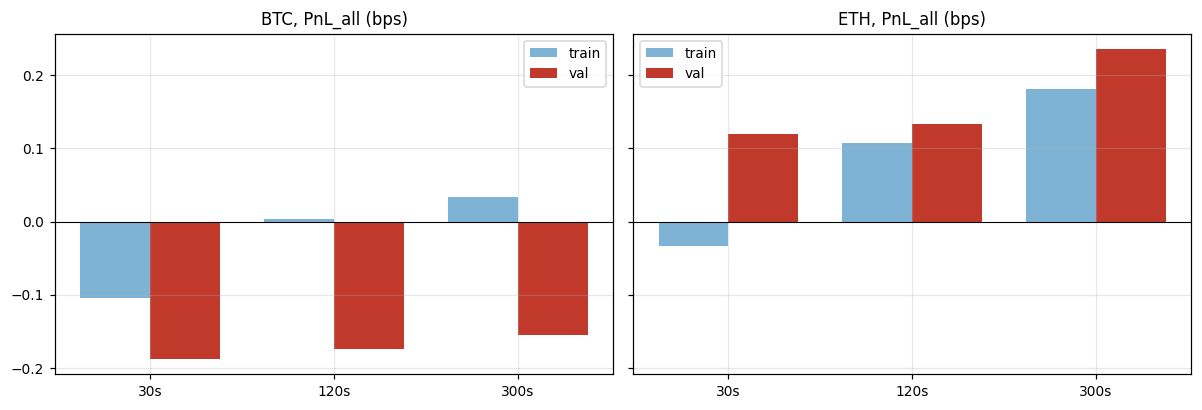

In [25]:
mk = pl.read_parquet(f"{OUT}/markout_baseline.parquet")
piv = (mk.pivot(values="PnL_all_bps", index=["symbol", "split"], on="tau")
        .sort("symbol", "split"))
print(piv)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, sym in zip(axes, ["btc", "eth"]):
    x = np.arange(len(TAUS)); wbar = 0.38
    for k, split in enumerate(["train", "val"]):
        vals = [mk.filter((pl.col("symbol")==sym)&(pl.col("split")==split)&(pl.col("tau")==t))["PnL_all_bps"][0] for t in TAUS]
        ax.bar(x + (k-0.5)*wbar, vals, wbar, label=split, color=["#7fb3d5", "#c0392b"][k])
    ax.axhline(0, color="k", lw=0.7); ax.set_xticks(x); ax.set_xticklabels([f"{t}s" for t in TAUS])
    ax.set_title(f"{sym.upper()}, PnL_all (bps)"); ax.legend()
plt.tight_layout(); plt.show()

- Toxicity is **worst at the short horizon (30 s)** and concentrated on **BTC**: BTC is negative
  on validation across *all* τ (−0.19 / −0.17 / −0.16, reproducing the team's figures exactly),
  while BTC train is toxic only at 30 s and recovers by 120–300 s (mean reversion).
- **BTC and ETH behave oppositely on validation**: ETH maker flow is *positive* on val
  (+0.12 / +0.13 / +0.24), the regime shift hurt BTC but not ETH. This matches the team's
  "opposite BTC/ETH validation behaviour" note and means one shared filter is risky.
- Everywhere, **longer τ is less toxic than 30 s** → partial mean reversion. The real
  filtering opportunity is **BTC at short horizons**, not ETH.

### 4.2 · Liquidation event study: forward mid path by cluster size (C3)

For every liquidation (anchored at its *available* time, Exchange 2 +200 ms), the **signed**
forward mid move `s_liq·(mid(L+τ) − mid(L))/mid(L)·1e4` (positive = price continues in the
liquidation's direction). Bucketed by the event's **cluster total notional** (Q5 = largest).

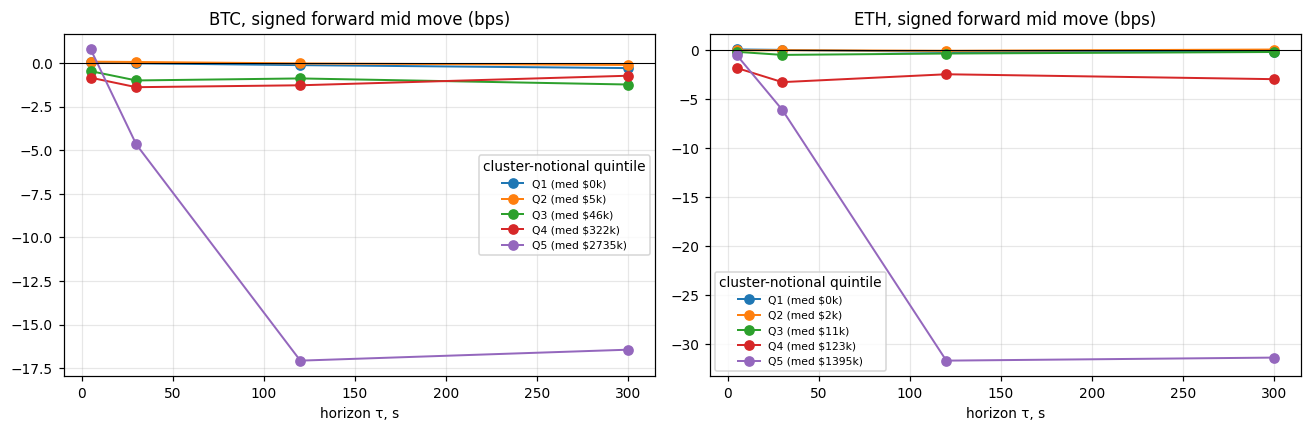

By exchange membership of the cluster (signed bps):
shape: (6, 7)
┌────────┬─────────────────┬────────┬───────────┬────────────┬─────────────┬─────────────┐
│ symbol ┆ group           ┆ n      ┆ signed_5s ┆ signed_30s ┆ signed_120s ┆ signed_300s │
│ ---    ┆ ---             ┆ ---    ┆ ---       ┆ ---        ┆ ---         ┆ ---         │
│ str    ┆ str             ┆ u32    ┆ f64       ┆ f64        ┆ f64         ┆ f64         │
╞════════╪═════════════════╪════════╪═══════════╪════════════╪═════════════╪═════════════╡
│ btc    ┆ both            ┆ 226145 ┆ -0.156559 ┆ -2.107218  ┆ -5.804558   ┆ -5.503686   │
│ btc    ┆ exchange_1_only ┆ 84083  ┆ 0.06958   ┆ 0.010272   ┆ -0.132847   ┆ -0.339321   │
│ btc    ┆ exchange_2_only ┆ 32682  ┆ 0.110215  ┆ -0.144749  ┆ -0.125835   ┆ -0.481689   │
│ eth    ┆ both            ┆ 162748 ┆ -0.896531 ┆ -3.465775  ┆ -12.272612  ┆ -12.259257  │
│ eth    ┆ exchange_1_only ┆ 104764 ┆ 0.106064  ┆ 0.027826   ┆ -0.135737   ┆ -0.210194   │
│ eth    ┆ exchange_2_on

In [26]:
es = pl.read_parquet(f"{OUT}/event_study.parquet")
q = es.filter(pl.col("cut") == "cluster_notional_quintile")
estaus = [5, 30, 120, 300]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, sym in zip(axes, ["btc", "eth"]):
    sub = q.filter(pl.col("symbol") == sym).sort("group")
    for row in sub.iter_rows(named=True):
        ax.plot(estaus, [row[f"signed_{t}s"] for t in estaus], marker="o", lw=1.3,
                label=f"{row['group']} (med ${row['cnotl_med']/1e3:.0f}k)")
    ax.axhline(0, color="k", lw=0.7)
    ax.set_title(f"{sym.upper()}, signed forward mid move (bps)")
    ax.set_xlabel("horizon τ, s"); ax.legend(fontsize=7, title="cluster-notional quintile")
plt.tight_layout(); plt.show()

print("By exchange membership of the cluster (signed bps):")
print(es.filter(pl.col("cut") == "exchange_membership")
       .select("symbol", "group", "n", "signed_5s", "signed_30s", "signed_120s", "signed_300s")
       .sort("symbol", "group"))

- **Cluster size is by far the strongest discriminator**, the largest-cluster bucket (Q5)
  shows forward moves an order of magnitude bigger than the smallest, confirming the team's
  finding that cluster total notional (not single-event amplitude) is the signal.
- The large-cluster path overshoots then mean-reverts by 120–300 s (BTC shows brief continuation
  at the 5 s horizon; ETH reverts from the start). That is why a maker filled into a cascade can be
  hurt at short τ yet see the price come back by 300 s.
- The exchange-membership cut shows the cross-exchange (`both`) clusters carry by far the largest
  moves; Exchange 2-only and Exchange 1-only are similar in this cut. (That Exchange 2 *leads* Exchange 1 is shown
  by the lead-lag impulse response in §3 (microstructure) above, not by this membership split.)

### 4.3 · Adverse selection: trade-activity burst after a liquidation (C4)

Trade notional in the **5 s after** each liquidation vs the all-period 5 s baseline.

shape: (4, 6)
┌────────┬────────────┬────────────────┬────────────────┬─────────────┬───────────────┐
│ symbol ┆ source     ┆ baseline_5s_$k ┆ post5s_mean_$k ┆ mult_mean_x ┆ mult_median_x │
│ ---    ┆ ---        ┆ ---            ┆ ---            ┆ ---         ┆ ---           │
│ str    ┆ str        ┆ i64            ┆ i64            ┆ f64         ┆ f64           │
╞════════╪════════════╪════════════════╪════════════════╪═════════════╪═══════════════╡
│ btc    ┆ exchange_2 ┆ 774            ┆ 23996          ┆ 31.0        ┆ 17.3          │
│ btc    ┆ exchange_1 ┆ 774            ┆ 5492           ┆ 7.1         ┆ 3.2           │
│ eth    ┆ exchange_2 ┆ 706            ┆ 24234          ┆ 34.3        ┆ 21.6          │
│ eth    ┆ exchange_1 ┆ 706            ┆ 5094           ┆ 7.2         ┆ 3.0           │
└────────┴────────────┴────────────────┴────────────────┴─────────────┴───────────────┘


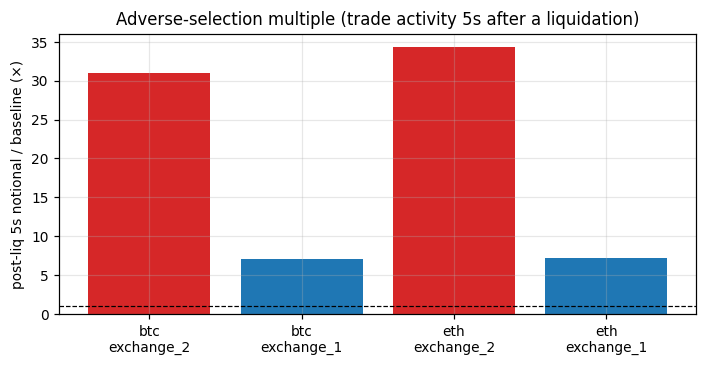

In [27]:
adv = json.load(open(f"{OUT}/adverse_selection.json"))
rows = []
for sym, d in adv.items():
    for src in ["exchange_2", "exchange_1"]:
        rows.append({"symbol": sym, "source": src, "baseline_5s_$k": round(d["baseline_5s_usd"]/1e3),
                     "post5s_mean_$k": round(d[f"{src}_post5s_mean_usd"]/1e3),
                     "mult_mean_x": round(d[f"{src}_mult_mean"], 1),
                     "mult_median_x": round(d[f"{src}_mult_median"], 1)})
adf = pl.DataFrame(rows)
print(adf)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
labels = [f"{r['symbol']}\n{r['source']}" for r in rows]
ax.bar(labels, [r["mult_mean_x"] for r in rows], color=["#d62728","#1f77b4"]*2)
ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set_ylabel("post-liq 5s notional / baseline (×)")
ax.set_title("Adverse-selection multiple (trade activity 5s after a liquidation)")
plt.tight_layout(); plt.show()

Trade activity in the 5 s after a Exchange 2 liquidation is **~30–34× baseline**,
reproducing the team's ~34× figure, a maker quoting through a cascade gets filled into a
burst of informed flow. This is the physical mechanism behind the toxic `PnL_all`.

### 4.4 · Feature set, leakage validation, IC / PSI / monotonicity (D)

Features are built **causally** for a reproducible 3M-trade reservoir sample per symbol
(`eda_compute.build_feature_sample`). All liquidation windows are strict `[t−W, t)` and
Exchange 2 is +200 ms-shifted before the merge. The 10 example features:

| feature | definition (all evaluated at trade time t) |
|---|---|
| `liq_notional_30s` / `_120s` | Σ combined-liq notional in `[t−W, t)` |
| `liq_event_count_30s` | # liquidations in `[t−30s, t)` |
| `liq_side_imbalance_30s` | (buy − sell) / total liq notional, 30s |
| `exchange_2_liq_notional_30s` | Exchange 2-only notional (after +200 ms), 30s |
| `liq_velocity` | `liq_notional_30s / (liq_notional_120s + 1)` |
| `time_since_liq_s` | seconds since the last liquidation before t |
| `bbo_spread_bps` | (ask − bid)/mid·1e4 at t (forward-filled) |
| `bbo_imbalance` | (bid_amt − ask_amt)/(bid_amt + ask_amt) at t |
| `mid_ret_5s` | trailing mid return over `[t−5s, t]`, bps |

#### 4.4.1 · Leakage / causality validation (E)

The reusable primitives in `eda_compute` are causal by construction. Below we (1) prove the
`[t−W, t)` window is **exclusive of t** (the boundary bug the team hit, `searchsorted` must
use `side='left'`), (2) show the leaky `side='right'` variant differs, and (3) run the
field validators (`no NaN / no inf / aligned`) on the real feature set.

In [28]:
src_ts = np.array([0, 5, 10], dtype=np.int64) * 1_000_000
val    = np.array([100.0, 200.0, 400.0])
prefix = np.concatenate([[0.0], np.cumsum(val)])
q = np.array([10], dtype=np.int64) * 1_000_000
W = 30_000_000
causal = E.causal_window_sum(src_ts, prefix, q, W)
hi_leak = np.searchsorted(src_ts, q, side="right")
leak = prefix[hi_leak] - prefix[np.searchsorted(src_ts, q - W, "left")]
print(f"causal [t-30s, t) sum at t=10s : {causal[0]:.0f}   (correct: 100+200, excludes the 400 AT t)")
print(f"leaky  [t-30s, t] sum at t=10s : {leak[0]:.0f}   (WRONG: pulls in the 400 happening AT t)")
assert causal[0] == 300.0 and leak[0] == 700.0
print("OK -> causal window is exclusive of t (no same-timestamp leakage)")

vr = pl.read_parquet(f"{OUT}/feature_validation.parquet")
print("\nValidators (no inf / no NaN / aligned to #trades):")
print(vr.select("symbol", "feature", "aligned", "n_inf", "nan_%", "ok"))
assert vr["ok"].all(), "a feature failed validation"
print("all features pass:", bool(vr["ok"].all()))

print("\nbroken feature ->", E.validate_feature("broken", np.array([1.0, np.inf, np.nan]), n_trades=5))

causal [t-30s, t) sum at t=10s : 300   (correct: 100+200, excludes the 400 AT t)
leaky  [t-30s, t] sum at t=10s : 700   (WRONG: pulls in the 400 happening AT t)
OK -> causal window is exclusive of t (no same-timestamp leakage)



Validators (no inf / no NaN / aligned to #trades):
shape: (20, 6)
┌────────┬─────────────────────────────┬─────────┬───────┬───────┬──────┐
│ symbol ┆ feature                     ┆ aligned ┆ n_inf ┆ nan_% ┆ ok   │
│ ---    ┆ ---                         ┆ ---     ┆ ---   ┆ ---   ┆ ---  │
│ str    ┆ str                         ┆ bool    ┆ i64   ┆ f64   ┆ bool │
╞════════╪═════════════════════════════╪═════════╪═══════╪═══════╪══════╡
│ btc    ┆ liq_notional_30s            ┆ true    ┆ 0     ┆ 0.0   ┆ true │
│ btc    ┆ liq_notional_120s           ┆ true    ┆ 0     ┆ 0.0   ┆ true │
│ btc    ┆ liq_event_count_30s         ┆ true    ┆ 0     ┆ 0.0   ┆ true │
│ btc    ┆ liq_side_imbalance_30s      ┆ true    ┆ 0     ┆ 0.0   ┆ true │
│ btc    ┆ exchange_2_liq_notional_30s ┆ true    ┆ 0     ┆ 0.0   ┆ true │
│ btc    ┆ liq_velocity                ┆ true    ┆ 0     ┆ 0.0   ┆ true │
│ btc    ┆ time_since_liq_s            ┆ true    ┆ 0     ┆ 0.0   ┆ true │
│ btc    ┆ bbo_spread_bps              ┆ true

#### 4.4.2 · Information coefficient (Spearman) vs forward markout

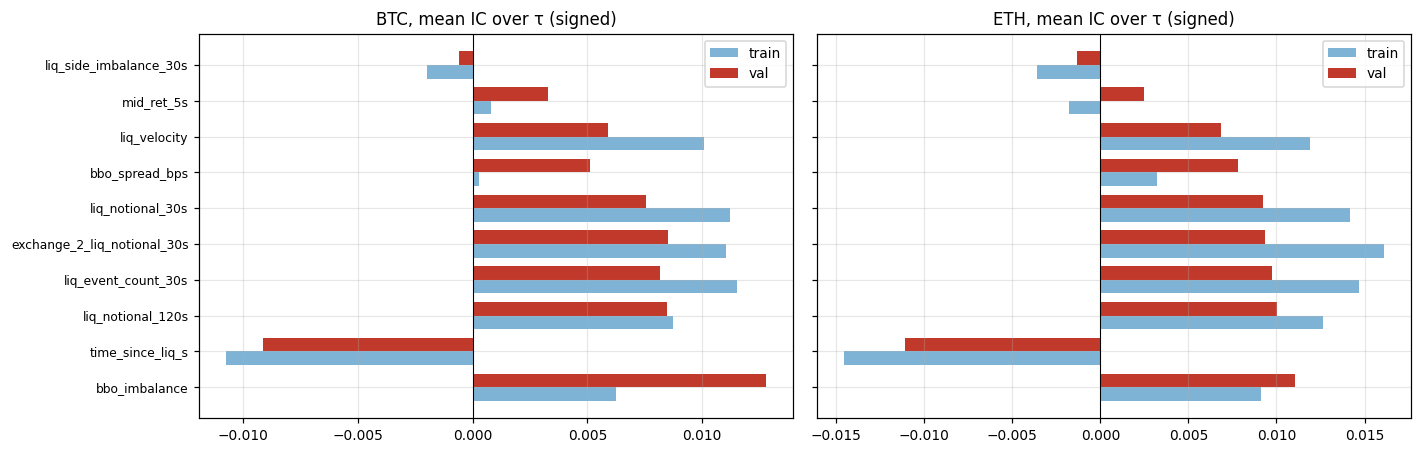

In [29]:
ic = pl.read_parquet(f"{OUT}/feature_ic.parquet")
order = (ic.filter(pl.col("split")=="val").group_by("feature")
          .agg(m=pl.col("IC").abs().mean()).sort("m", descending=True)["feature"].to_list())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, sym in zip(axes, ["btc", "eth"]):
    sub = ic.filter(pl.col("symbol") == sym)
    y = np.arange(len(order))
    for k, split in enumerate(["train", "val"]):
        m = [sub.filter((pl.col("feature")==f)&(pl.col("split")==split))["IC"].mean() for f in order]
        ax.barh(y + (k-0.5)*0.38, m, 0.38, label=split, color=["#7fb3d5","#c0392b"][k])
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8); ax.invert_yaxis()
    ax.axvline(0, color="k", lw=0.7); ax.set_title(f"{sym.upper()}, mean IC over τ (signed)"); ax.legend()
plt.tight_layout(); plt.show()

Absolute ICs are small (~0.01). Under an iid null the SE at n≈3M is ~0.0006, so
0.01 is nominally ~15σ, but trades are far from iid (clustered by time/volatility/bursts), so
the *effective* n is much smaller; read these as **small-but-real signals, not strong alpha**.
**Liquidation features and BBO imbalance carry the most**, matching the team's ranking, and
signs/magnitudes are **not stable train→val** (the regime shift), the key modelling risk.

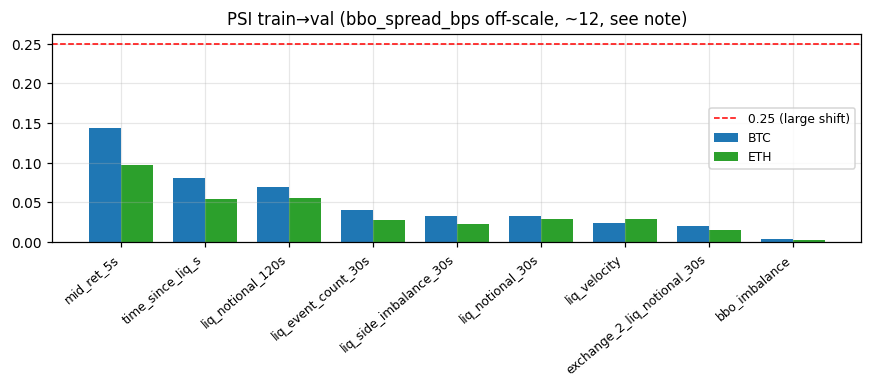

In [30]:
psi = pl.read_parquet(f"{OUT}/feature_psi.parquet")
fig, ax = plt.subplots(figsize=(8, 3.6))
sub = psi.filter(pl.col("feature") != "bbo_spread_bps").sort("psi", descending=True)
feats = sub["feature"].unique(maintain_order=True).to_list()
for k, sym in enumerate(["btc", "eth"]):
    vals = [psi.filter((pl.col("symbol")==sym)&(pl.col("feature")==f))["psi"][0] for f in feats]
    ax.bar(np.arange(len(feats)) + (k-0.5)*0.38, vals, 0.38, label=sym.upper(), color=SYM_C[sym])
ax.axhline(0.25, color="r", ls="--", lw=1, label="0.25 (large shift)")
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=40, ha="right", fontsize=8)
ax.set_title("PSI train→val (bbo_spread_bps off-scale, ~12, see note)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **Note on `bbo_spread_bps` (PSI ≈ 12, off-scale):** not a binning artifact, the train decile
> edges are distinct. The spread is ~1 tick ≈99% of the time in *both* splits; in **bps** it rose
> because BTC's price fell (\$98k→\$60k), so a fixed \$0.1 tick is mechanically more bps. It's a
> price-level/tick-arithmetic shift, not a liquidity-regime change.

#### 4.4.3 · Monotonicity (decile of feature vs mean markout) & feature correlation

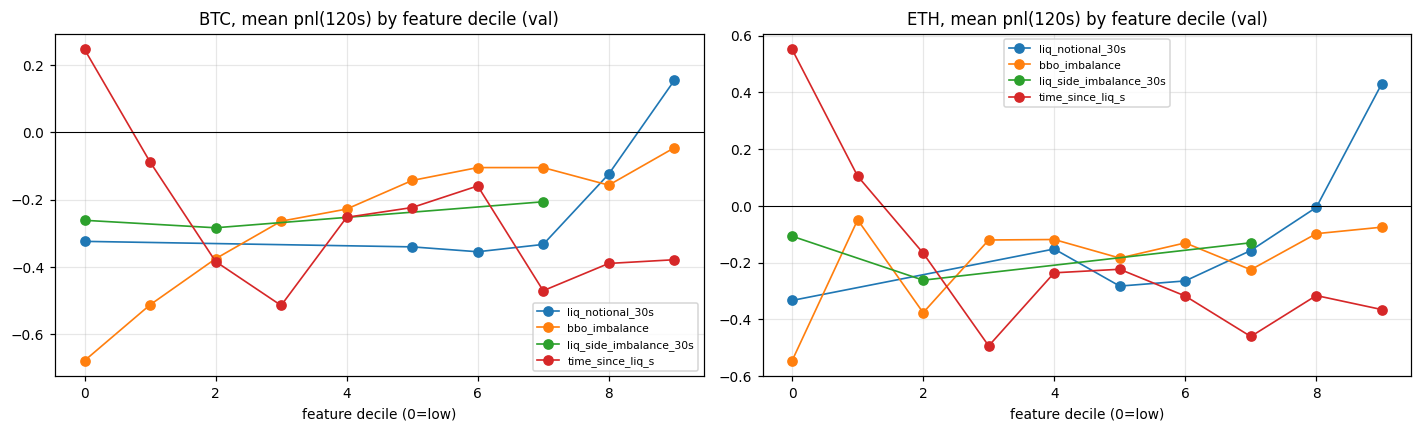

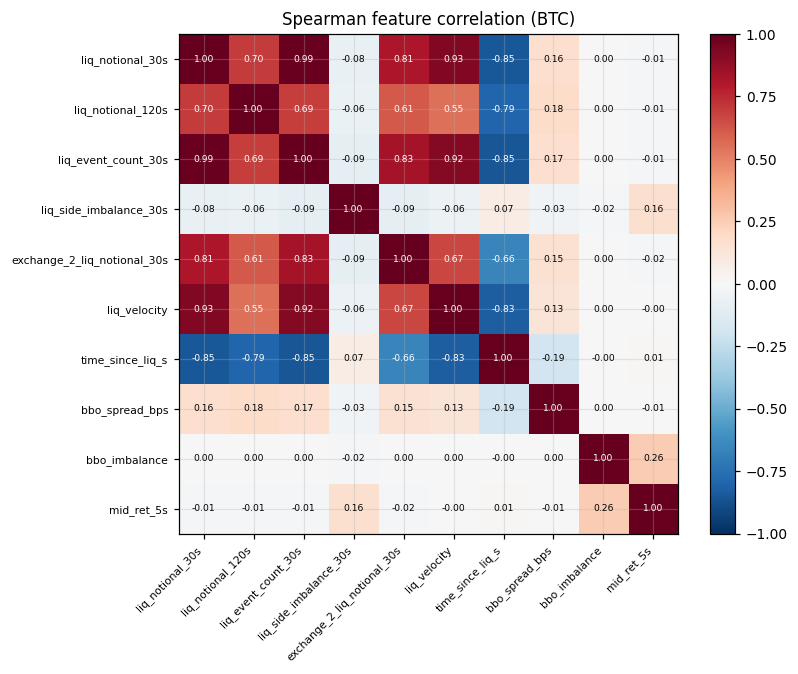

In [31]:
dec = pl.read_parquet(f"{OUT}/feature_decile.parquet")
show = ["liq_notional_30s", "bbo_imbalance", "liq_side_imbalance_30s", "time_since_liq_s"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, sym in zip(axes, ["btc", "eth"]):
    for f in show:
        d = dec.filter((pl.col("symbol")==sym)&(pl.col("feature")==f)).with_columns(pl.col("dec").cast(pl.Int32)).sort("dec")
        ax.plot(d["dec"], d["pnl120"], marker="o", lw=1.1, label=f)
    ax.axhline(0, color="k", lw=0.7); ax.set_title(f"{sym.upper()}, mean pnl(120s) by feature decile (val)")
    ax.set_xlabel("feature decile (0=low)"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

corr = json.load(open(f"{OUT}/feature_corr.json"))["btc"]
M = np.array(corr["matrix"]); feats = corr["features"]
fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats, fontsize=7)
for i in range(len(feats)):
    for j in range(len(feats)):
        ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(M[i,j])>0.5 else "black")
ax.set_title("Spearman feature correlation (BTC)"); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

### 4.5 · Baseline filter: why naive size-thresholds don't help (D3)

`Score(τ) = PnL_kept − PnL_all` on the sample for two rule families, swept over thresholds:
**symmetric** (filter if `liq_notional_30s ≥ θ`) and **directional** (filter only when the
liquidation pressure is *adverse* to the maker's side and sizable).

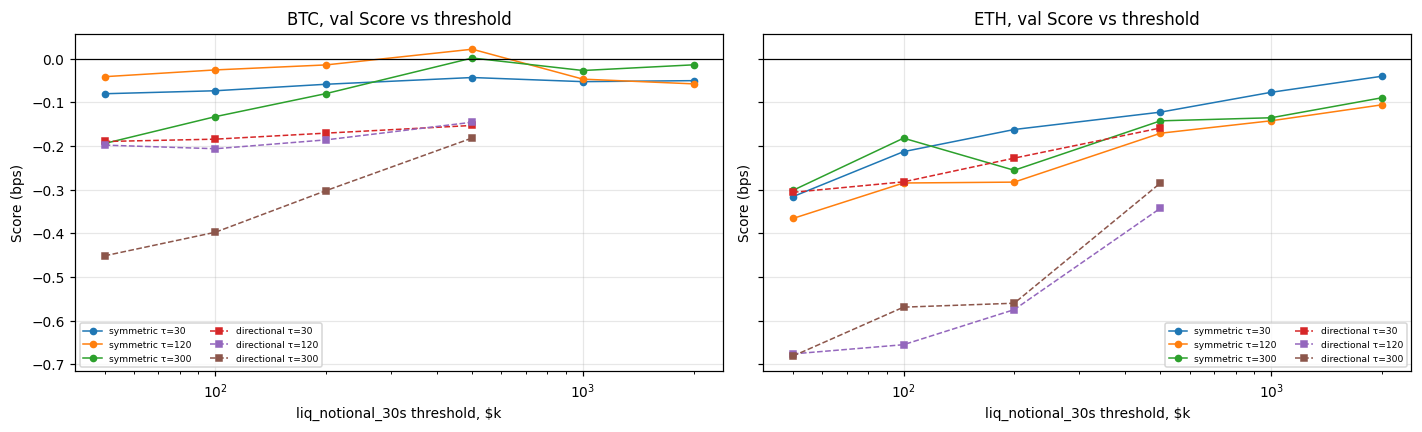

shape: (6, 6)
┌────────┬─────┬───────────┬───────────┬───────────┬────────┐
│ symbol ┆ tau ┆ PnL_all   ┆ PnL_kept  ┆ Score     ┆ kept_% │
│ ---    ┆ --- ┆ ---       ┆ ---       ┆ ---       ┆ ---    │
│ str    ┆ i64 ┆ f64       ┆ f64       ┆ f64       ┆ f64    │
╞════════╪═════╪═══════════╪═══════════╪═══════════╪════════╡
│ btc    ┆ 30  ┆ -0.229285 ┆ -0.287498 ┆ -0.058213 ┆ 91.1   │
│ btc    ┆ 120 ┆ -0.194251 ┆ -0.208154 ┆ -0.013903 ┆ 91.1   │
│ btc    ┆ 300 ┆ -0.23767  ┆ -0.317274 ┆ -0.079604 ┆ 91.1   │
│ eth    ┆ 30  ┆ 0.059091  ┆ -0.102805 ┆ -0.161895 ┆ 93.5   │
│ eth    ┆ 120 ┆ 0.203568  ┆ -0.078873 ┆ -0.282441 ┆ 93.5   │
│ eth    ┆ 300 ┆ 0.276838  ┆ 0.021533  ┆ -0.255306 ┆ 93.5   │
└────────┴─────┴───────────┴───────────┴───────────┴────────┘


In [32]:
rule = pl.read_parquet(f"{OUT}/baseline_rule.parquet")
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, sym in zip(axes, ["btc", "eth"]):
    for rl, mk_ in [("symmetric_notional","o-"), ("directional_adverse","s--")]:
        for tau in TAUS:
            s = (rule.filter((pl.col("symbol")==sym)&(pl.col("rule")==rl)&(pl.col("tau")==tau)&(pl.col("split")=="val"))
                    .sort("param"))
            ax.plot(s["param"]/1e3, s["Score"], mk_, lw=1, ms=4, label=f"{rl.split('_')[0]} τ={tau}")
    ax.axhline(0, color="k", lw=0.8); ax.set_xscale("log")
    ax.set_title(f"{sym.upper()}, val Score vs threshold"); ax.set_xlabel("liq_notional_30s threshold, $k")
    ax.set_ylabel("Score (bps)"); ax.legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()
print(rule.filter((pl.col("split")=="val")&(pl.col("rule")=="symmetric_notional")&(pl.col("param")==200000))
         .select("symbol","tau","PnL_all","PnL_kept","Score","kept_%").sort("symbol","tau"))

Essentially every naive liquidation-size filter,
symmetric **and** directional, across thresholds and τ, gives a **negative** validation
Score (min −0.68). The only positives are two BTC points at θ ≈ \$500k (max +0.022 bps, within
sampling noise and not robust across τ), and Score → 0 as the threshold keeps everything.
Filtering high-liquidation-context trades mostly **removes** trades that, post-cascade,
mean-revert favourably for the maker (consistent with the §4.2 reversion and with teammates
who reported simple thresholds don't produce a stable positive Score). ETH makes this worse:
its val flow is already positive (§4.1), so there is little to gain by filtering it at all.

The toxic moments are the **violent intra-cascade bursts** (§4.3), not "any 30 s window with
≥ θ liquidations." Capturing them needs finer, side- and horizon-aware structure, i.e. the
modelling/feature-infrastructure step, not a single global threshold. The clean, validated,
leak-free feature set + causal primitives here are the substrate for that.

### 4.6 · Liquidations add information beyond queue imbalance, directionally (D4)

Naive size filters failed (§4.5), so the question is: once you account for the dominant
short-horizon **queue-imbalance** adverse selection, do liquidations still carry signal? Define,
per trade, `imb_against = s·bbo_imbalance` and `liq_against = s·liq_side_imbalance_30s`
(>0 = that flow pushed *against* the maker's filled side). Residualise markout within imbalance
deciles to test orthogonality.

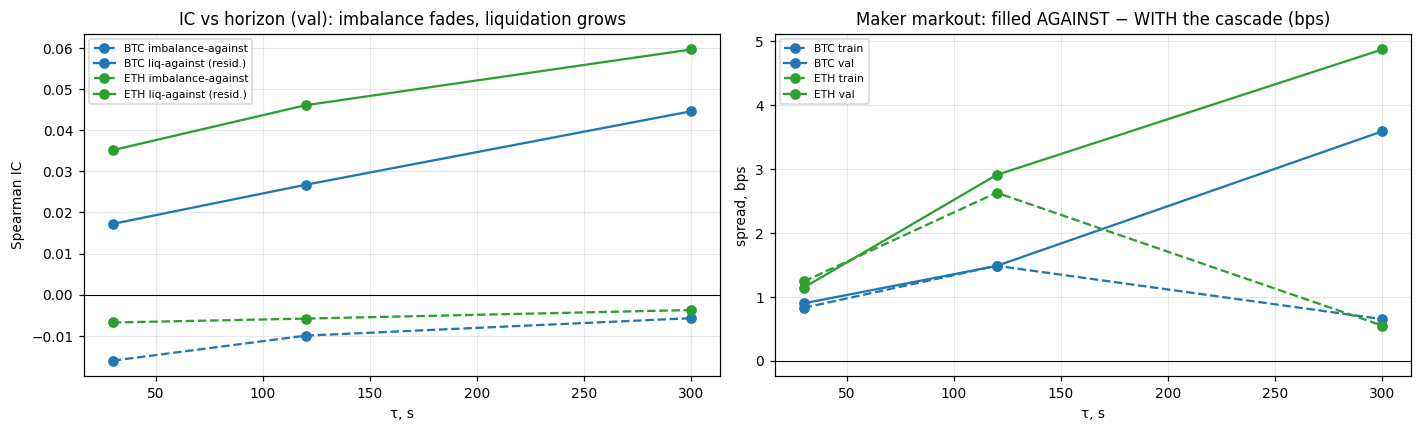

shape: (6, 6)
┌────────┬─────┬───────────┬──────────┬───────────┬──────────┐
│ symbol ┆ tau ┆ baseline  ┆ against  ┆ with_push ┆ spread   │
│ ---    ┆ --- ┆ ---       ┆ ---      ┆ ---       ┆ ---      │
│ str    ┆ i64 ┆ f64       ┆ f64      ┆ f64       ┆ f64      │
╞════════╪═════╪═══════════╪══════════╪═══════════╪══════════╡
│ btc    ┆ 30  ┆ -0.270578 ┆ 0.314641 ┆ -0.582699 ┆ 0.897341 │
│ btc    ┆ 120 ┆ -0.261495 ┆ 0.655971 ┆ -0.827616 ┆ 1.483587 │
│ btc    ┆ 300 ┆ -0.232944 ┆ 1.742697 ┆ -1.849609 ┆ 3.592306 │
│ eth    ┆ 30  ┆ -0.159148 ┆ 0.69131  ┆ -0.452679 ┆ 1.143989 │
│ eth    ┆ 120 ┆ -0.192626 ┆ 1.471146 ┆ -1.438092 ┆ 2.909238 │
│ eth    ┆ 300 ┆ -0.072424 ┆ 2.331955 ┆ -2.542847 ┆ 4.874801 │
└────────┴─────┴───────────┴──────────┴───────────┴──────────┘


In [33]:
ic = pl.read_parquet(f"{OUT}/conditional_ic.parquet")
cm = pl.read_parquet(f"{OUT}/conditional_means.parquet")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for sym, c in [("btc", "#1f77b4"), ("eth", "#2ca02c")]:
    v = ic.filter((pl.col("symbol") == sym) & (pl.col("split") == "val")).sort("tau")
    ax[0].plot(v["tau"], v["ic_imb_against"], "o--", color=c, label=f"{sym.upper()} imbalance-against")
    ax[0].plot(v["tau"], v["ic_liq_against_resid"], "o-", color=c, label=f"{sym.upper()} liq-against (resid.)")
ax[0].axhline(0, color="k", lw=0.7); ax[0].set(title="IC vs horizon (val): imbalance fades, liquidation grows",
            xlabel="τ, s", ylabel="Spearman IC"); ax[0].legend(fontsize=7)
for sym, c in [("btc", "#1f77b4"), ("eth", "#2ca02c")]:
    for split, ls in [("train", "--"), ("val", "-")]:
        m = cm.filter((pl.col("symbol") == sym) & (pl.col("split") == split)).sort("tau")
        ax[1].plot(m["tau"], m["spread"], ls, marker="o", color=c, label=f"{sym.upper()} {split}")
ax[1].axhline(0, color="k", lw=0.7); ax[1].set(title="Maker markout: filled AGAINST − WITH the cascade (bps)",
            xlabel="τ, s", ylabel="spread, bps"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
print(cm.filter(pl.col("split") == "val").select("symbol","tau","baseline","against","with_push","spread"))

- **Two orthogonal effects on different horizons.** Queue imbalance is **short-horizon adverse
  selection** (IC negative, ~−0.016 at 30 s, fading by 300 s — this is the maker-markout target, opposite in sign to the +0.385 vs forward mid return in §3.1). The directional liquidation signal
  is the **opposite**: IC *positive and growing* with τ (BTC +0.018→+0.045, ETH +0.035→+0.060 — larger than the ~0.01 raw example-feature ICs in §4.4.2 because this is a conditional directional contrast), and
  **residualising out imbalance barely changes it** (resid ≈ raw) → liquidations add information
  imbalance does not contain.
- **The mechanism is reversion, and it flips the maker's outcome.** In active-liq windows, a maker
  filled **against** the cascade (e.g. selling into a buy-cascade) earns **+1.7 / +2.3 bps** (BTC/ETH)
  by 300 s; filled **with** it, **−1.9 / −2.5 bps**. The against−with spread grows to ~**+3.6 / +4.9 bps**,
  and the **sign is stable on train and val** (magnitude larger in the stressed val regime).
- **Why §4.5's naive filters failed:** they removed high-liq trades indiscriminately, but the
  against-the-cascade ones have **positive markout**. The signal is **directional** (the cascade
  direction relative to the fill side), not "filter when liquidations are large."

### Section summary (parts C–E)

- **4.1** Full-data `PnL_all(τ)`: toxicity is concentrated at 30 s and on **BTC** (toxic on
  val); **ETH is positive on val**, opposite behaviour, so BTC/ETH likely need separate filters.
- **4.2** Cluster size is the dominant predictor of forward mid moves (continuation → reversion);
  Exchange 2-touching clusters move price most.
- **4.3** ~30–34× trade-activity burst in the 5 s after a Exchange 2 liquidation = the physical
  adverse-selection mechanism.
- **4.4** 10 causal, leak-validated features; liq + BBO-imbalance carry the most (small) IC,
  unstable across the regime shift; correlation/PSI/monotonicity all characterised.
- **4.5** Naive (symmetric/size) filters don't beat the baseline, they remove the wrong trades.
- **4.6** Liquidations **do** add signal beyond imbalance, **directionally**: short-horizon imbalance
  adverse selection vs longer-horizon liquidation **reversion** (orthogonal; against−with spread
  ~+3.6/+4.9 bps at 300 s, stable train+val). The signal is the cascade direction vs the fill side, not raw size.
- **4.4.1** The reusable causal primitives + validators (`eda_compute`, part E) are the foundation
  for the feature-class task.